## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## **Please read the instructions carefully before starting the project.**

This is a commented Python notebook file containing all the instructions and tasks to be performed for the project.
* Blanks ('\_\_\_\_\_\__') are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines (like `"# write your code here"` or `"# complete the code"`). Running incomplete code may throw an error.
* Please sequentially run the codes from the beginning to avoid any unnecessary errors.
* Add the results obtained, observations, insights, and recommendations from the analysis in the presentation and submit the same.

## Installing and Importing the Necessary libraries

In [2]:
# Installing the libraries with the specified version.
#!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [29]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [30]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [31]:
Loan = pd.read_csv("Loan_Modelling.csv")   ##  Complete the code to read the data



In [32]:
# copying data to another variable to avoid any changes to original data
data = Loan.copy()
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [33]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


### Data Overview and Summary Statistics

The dataset contains 5000 customer records with 14 variables describing demographic, financial, and behavioral characteristics.

The target variable, Personal_Loan, shows that only 9.6% of customers accepted the loan, indicating a class imbalance problem. Therefore, evaluation metrics such as recall, precision, and F1-score will be more important than accuracy.

Income and CCAvg exhibit right-skewed distributions, with a small number of high-value customers, suggesting that these variables may be strong predictors of loan acceptance.

The Experience variable contains negative values, which are not logically valid and indicate data quality issues that will need to be addressed during preprocessing.

Mortgage values are highly skewed, with many customers having no mortgage and a few having very high values.

Binary variables such as CD_Account, Securities_Account, and Online usage represent customer engagement and are likely to play an important role in predicting loan acceptance.

## Data Overview

### View the first and last 5 rows of the dataset.

In [34]:
data.head() ##  Complete the code to view top 5 rows of the data

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [35]:
data.tail()  ##  Complete the code to view last 5 rows of the data

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Understand the shape of the dataset.

In [36]:
data.shape  ## Complete the code to get the shape of the data

(5000, 14)

### Check the data types of the columns for the dataset

In [37]:
data.info()  ##  Complete the code to view the datatypes of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


### Checking the Statistical Summary

In [38]:
data.describe().T  ## Complete the code to print the statistical summary of the data

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


### Dropping columns

In [39]:
#data = data.drop(["ID","ZIPCode"], axis=1)  ## Complete the code to drop a column from the dataframe

## Data Preprocessing

### Checking for Anomalous Values

In [40]:
data["Experience"].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

In [41]:
# checking for experience <0
data[data["Experience"] < 0]["Experience"].unique()

array([-1, -2, -3])

In [42]:
# Correcting the experience values
data["Experience"].replace(-1, 1, inplace=True)
data["Experience"].replace(-2, 2, inplace=True)
data["Experience"].replace(-3, 3, inplace=True)

In [43]:
data["Education"].unique()

array([1, 2, 3])

### Feature Engineering

In [44]:
# checking the number of uniques in the zip code
data["ZIPCode"].nunique()

467

In [45]:
data["ZIPCode"] = data["ZIPCode"].astype(str)
print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    data["ZIPCode"].str[0:2].nunique(),
)
data["ZIPCode"] = data["ZIPCode"].str[0:2]

data["ZIPCode"] = data["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


In [48]:
## Converting the data type of categorical features to 'category'
cat_cols = [
    "Education",
    "Personal_Loan",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard",
    "ZIPCode",
]
data[cat_cols] = data[cat_cols].astype("category")

## <a name='link2'>Exploratory Data Analysis (EDA)</a>


### Univariate Analysis

In [49]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [50]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

## Exploratory Data Analysis (EDA) – Insights & Recommendations

### 1. Income
- The distribution of income is **right-skewed**, with most customers earning between **$30K–$100K**.
- There are a few **high-income outliers (>$150K–$200K)**.
- The mean is higher than the median, confirming skewness.

**Insight:**
- High-income customers likely represent a **key target segment for personal loan conversion**.

**Recommendation:**
- Create **targeted marketing strategies** for high-income customers (e.g., premium loan products, wealth management offers).

---

### 2. CCAvg (Credit Card Average Spending)
- Highly **right-skewed distribution** with most customers spending **< $3K/month**.
- Significant number of **extreme outliers (up to ~$10K)**.

**Insight:**
- Customers with high credit card spending indicate **higher financial activity and borrowing potential**.

**Recommendation:**
- Use **CCAvg as a strong predictor** in modeling.
- Consider **segmenting high spenders** for cross-selling loans.

---

### 3. Mortgage
- Extremely **right-skewed**, with a large number of customers having **zero mortgage**.
- Few customers have very high mortgage values (outliers up to ~$600K).

**Insight:**
- Majority of customers **do not currently hold mortgages**, indicating potential untapped lending opportunities.

**Recommendation:**
- Target customers without mortgages for **loan acquisition campaigns**.
- Consider transforming this feature (e.g., log transformation or binning) due to skewness.

---

### 4. Age
- Fairly **normally distributed**, centered around **45 years**.
- Range spans from early 20s to mid-60s.

**Insight:**
- The dataset represents a **balanced working-age population**.

**Recommendation:**
- Segment customers by age groups (e.g., early career, mid-career, pre-retirement) to **tailor financial products**.

---

### 5. Experience
- Appears relatively **uniformly distributed**, but includes **negative values**, which are unrealistic.

**Insight:**
- Negative experience values likely indicate **data quality issues**.

**Recommendation:**
- Clean the data by:
  - Replacing negative values with **median/mean**
  - Or removing those records
- This is critical before modeling to avoid bias.

---

### 6. Overall Observations
- Several variables (Income, CCAvg, Mortgage) are **heavily skewed with outliers**.
- These features may impact model performance if not handled properly.

**Recommendations for Modeling:**
- Apply:
  - **Log transformation** for skewed variables
  - **Outlier treatment (capping/winsorization)**
- Normalize/scale features if using distance-based models.

---

### Business Summary
- The bank has a strong opportunity to:
  - Target **high-income and high-spending customers**
  - Convert **non-mortgage holders into loan customers**
- Data cleaning (especially Experience) and feature transformation will be critical for building an accurate predictive model.


#### Observations on Age

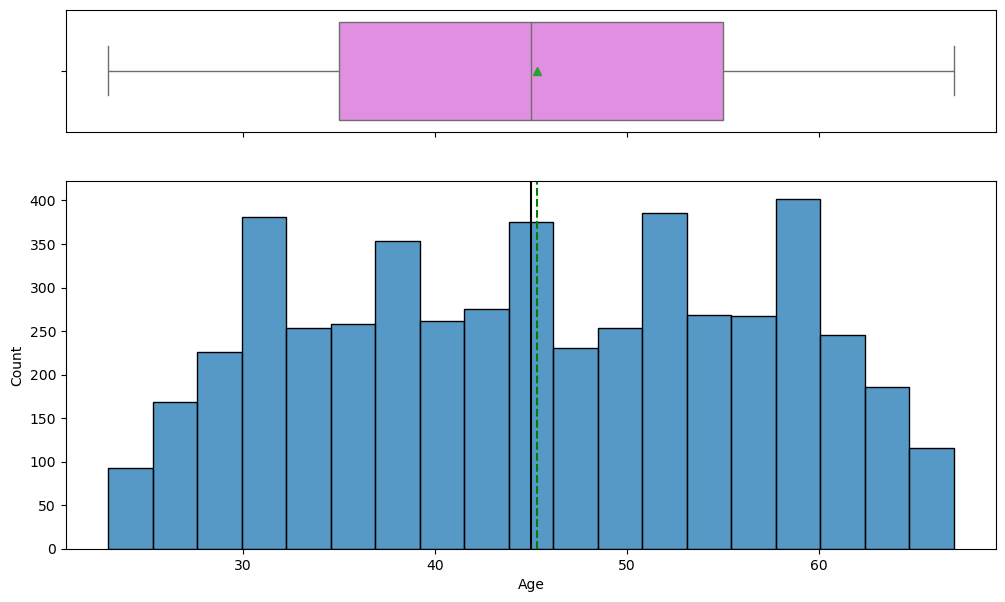

In [57]:
histogram_boxplot(data,"Age")

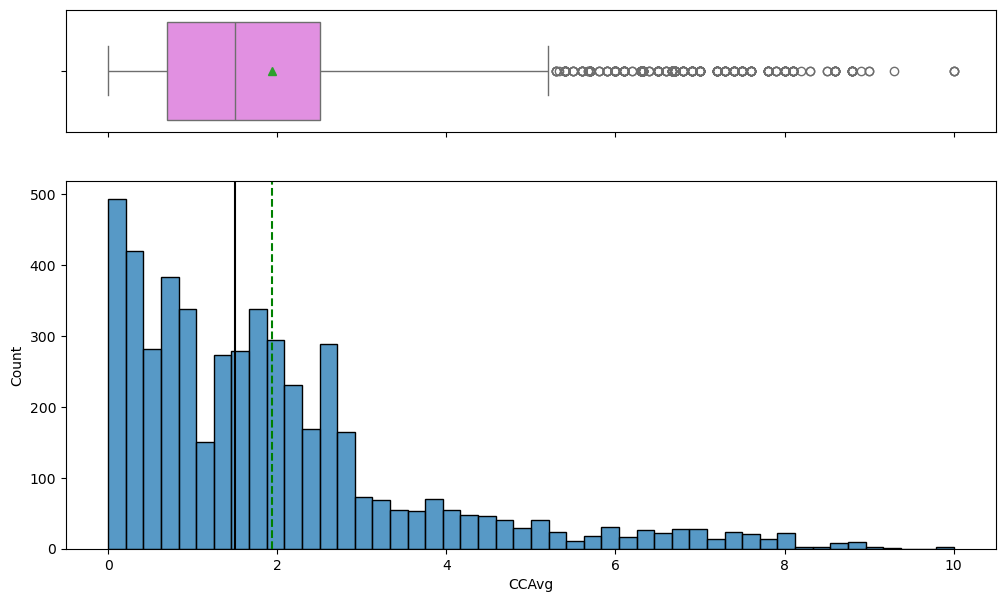

In [59]:
# Observations on CCAvg
histogram_boxplot(data, "CCAvg")   # or histogram_boxplot(data["CCAvg"]) depending on how the function was defined



#### Q1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

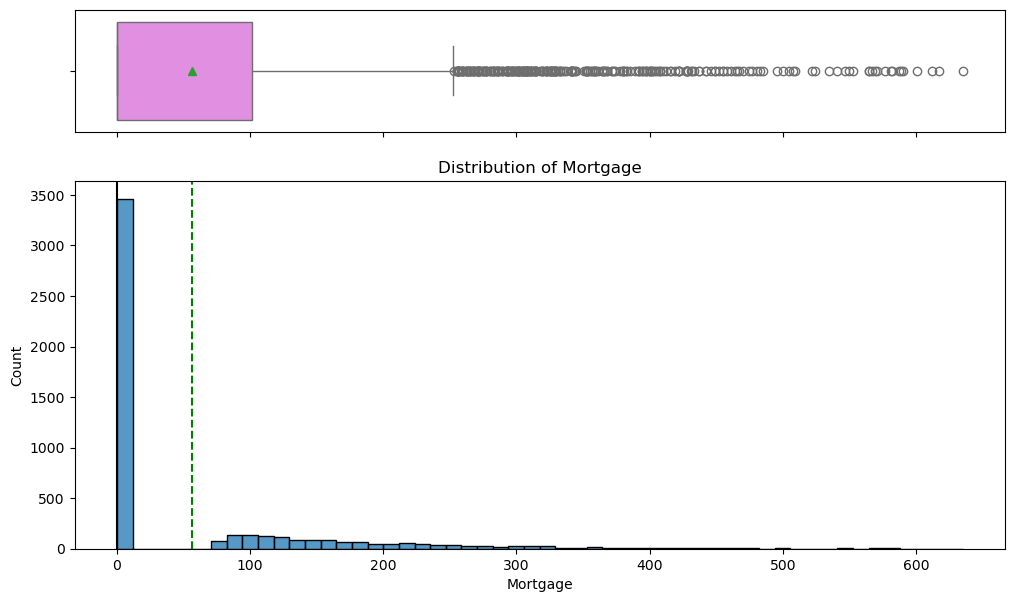

In [72]:
histogram_boxplot(data,"Mortgage")  ## Complete the code to create histogram_boxplot for Mortgage
plt.title("Distribution of Mortgage")
plt.show()

#### Observations on Experience

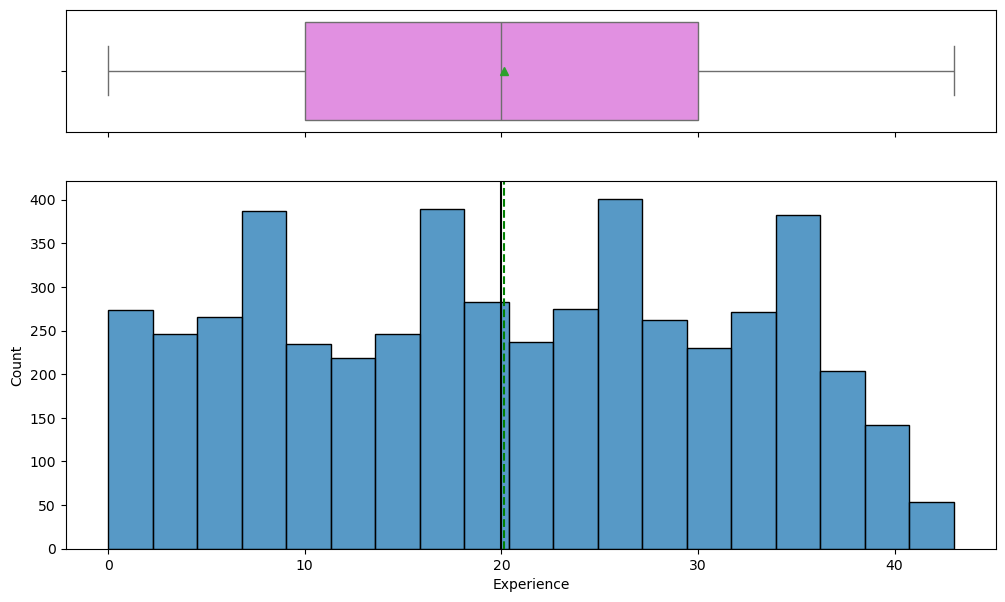

In [62]:
histogram_boxplot(data, "Experience") ## Complete the code to create histogram_boxplot for experience

#### Observations on Income

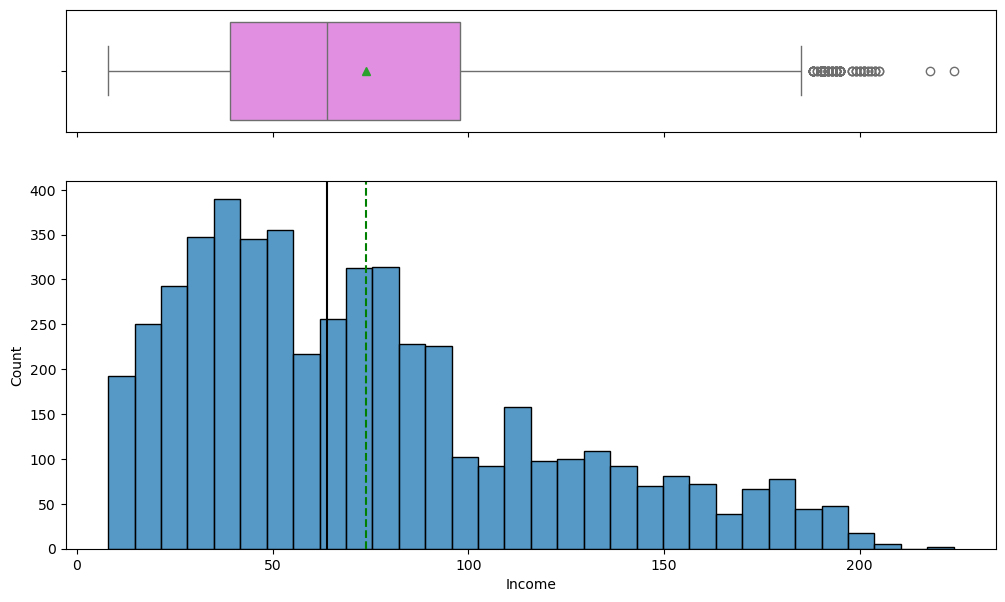

In [61]:
histogram_boxplot(data, "Income")  ## Complete the code to create histogram_boxplot for Income

#### Observations on CCAvg

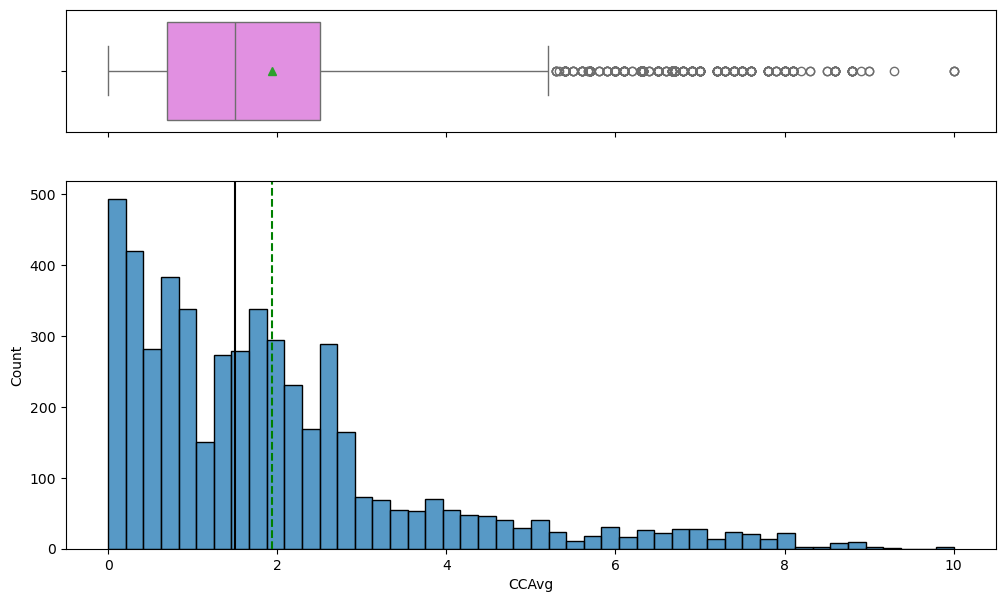

In [60]:
histogram_boxplot(data,"CCAvg")  ## Complete the code to create histogram_boxplot for CCAvg

#### Observations on Family

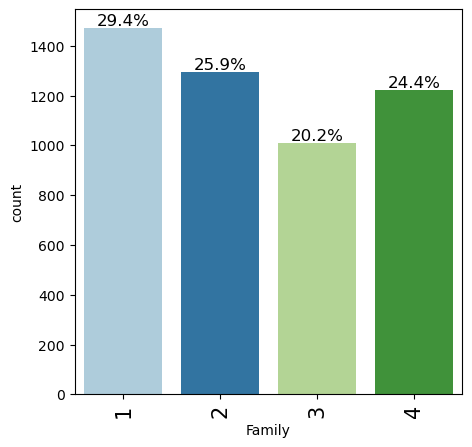

In [63]:
labeled_barplot(data, "Family", perc=True)

#### Q2. How many customers have credit cards?

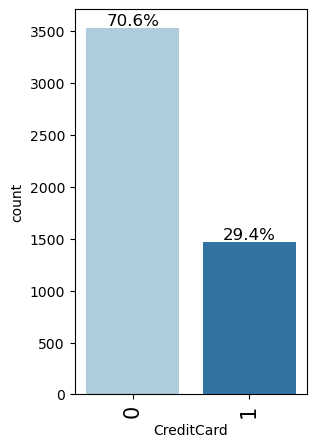

In [67]:
labeled_barplot(data, "CreditCard", perc=True)   ## Complete the code to create labeled_barplot for CreditCard

#### Observations on Education

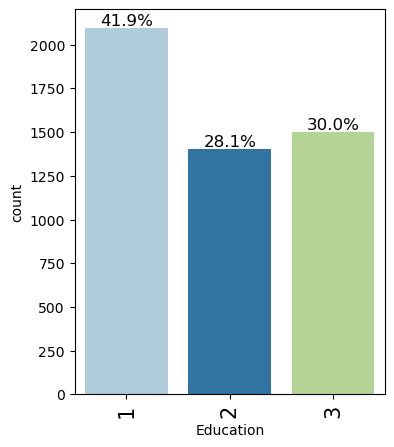

In [65]:
labeled_barplot(data, "Education", perc=True)   ## Complete the code to create labeled_barplot for Education

#### Observations on Securities_Account

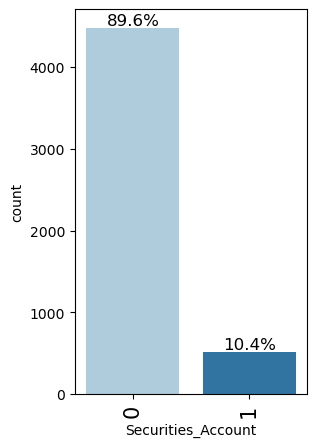

In [68]:
labeled_barplot(data, "Securities_Account", perc=True)   ## Complete the code to create labeled_barplot for Securities_Account

#### Observations on CD_Account

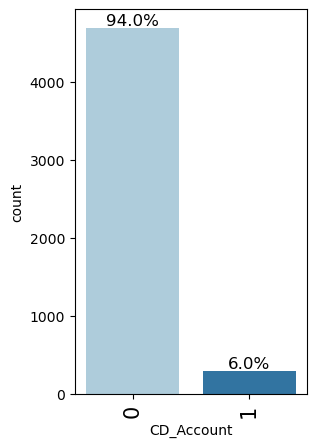

In [69]:
labeled_barplot(data, "CD_Account", perc=True)   ## Complete the code to create labeled_barplot for CD_Account

#### Observations on Online

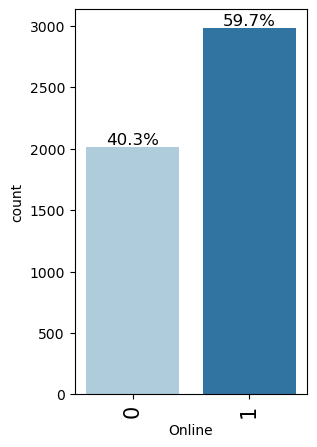

In [70]:
labeled_barplot(data, "Online", perc=True)   ## Complete the code to create labeled_barplot for Online

#### Observation on ZIPCode

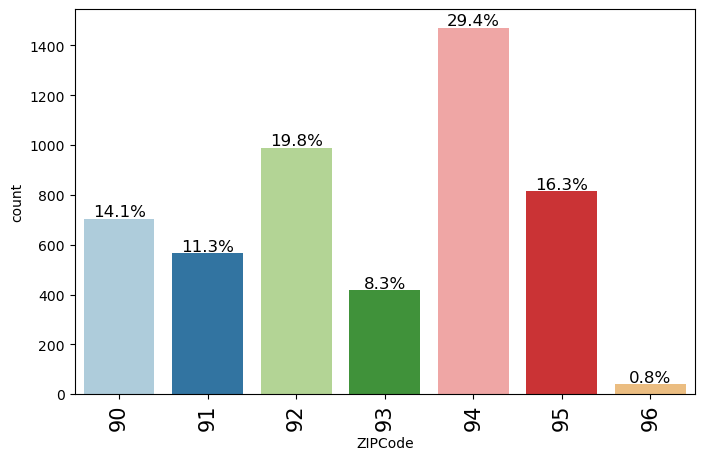

In [71]:
labeled_barplot(data, "ZIPCode", perc=True)   ## Complete the code to create labeled_barplot for ZIPCode

### Bivariate Analysis

In [73]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [74]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

#### Q3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

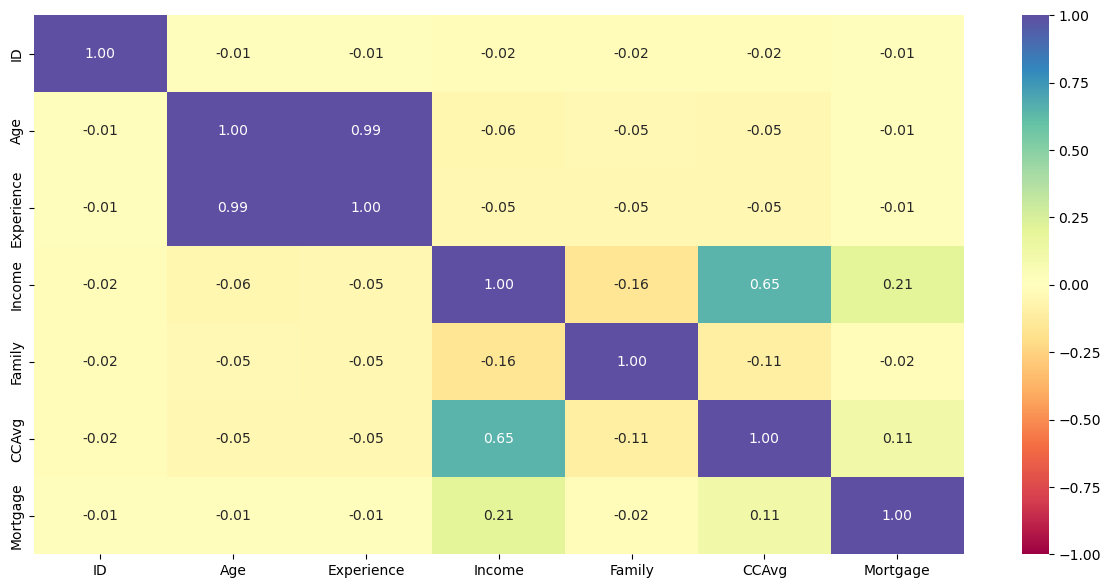

In [75]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral") # Complete the code to get the heatmap of the data
plt.show()

## Q3. Correlation Analysis

The heatmap illustrates the relationships between numerical variables in the dataset.

### Key Observations:

- **Income and CCAvg show a strong positive correlation (0.65)**  
  This indicates that customers with higher income tend to have higher credit card spending. These two variables together may be strong predictors of customer financial behavior.

- **Age and Experience are almost perfectly correlated (0.99)**  
  This suggests strong multicollinearity, as both variables essentially capture the same information (work experience increases with age).

- **Income and Mortgage have a moderate positive correlation (0.21)**  
  Customers with higher income are more likely to have higher mortgage values.

- **Income and Family show a slight negative relationship (-0.16)**  
  This suggests a weak inverse relationship but is not strong enough to be a major driver.

- Most other variables show **very weak or negligible correlations**, indicating they are relatively independent.

### Important Insight:

- Since **Age and Experience are highly correlated**, one of them should be removed during modeling to avoid multicollinearity issues.

- **Income and CCAvg stand out as the most influential financial variables**, and are likely to play a key role in predicting Personal Loan acceptance.

### Conclusion:

The most important features from this correlation analysis are:
- Income
- CCAvg

Additionally, care must be taken to handle:
- Multicollinearity between Age and Experience

These insights will help improve model performance and interpretability.

#### Q4. How does a customer's interest in purchasing a loan vary with their education?

Personal_Loan     0    1   All
Experience                    
All            4520  480  5000
9               127   20   147
8               101   18   119
3               116   17   133
20              131   17   148
12               86   16   102
5               132   14   146
32              140   14   154
26              120   14   134
25              128   14   142
19              121   14   135
16              114   13   127
37              103   13   116
35              130   13   143
30              113   13   126
23              131   13   144
22              111   13   124
11              103   13   116
31               92   12   104
36              102   12   114
6               107   12   119
18              125   12   137
7               109   12   121
29              112   12   124
28              127   11   138
17              114   11   125
13              106   11   117
21              102   11   113
39               75   10    85
34              115   10   125
27      

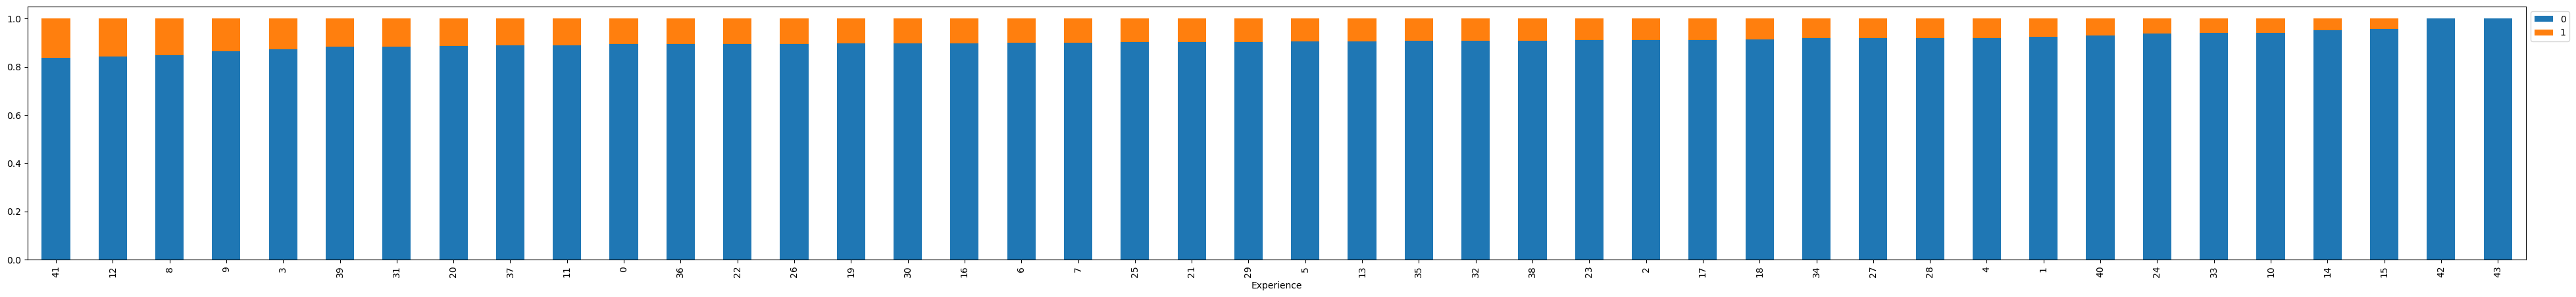

In [76]:
stacked_barplot(data, "Experience", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and Experience

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


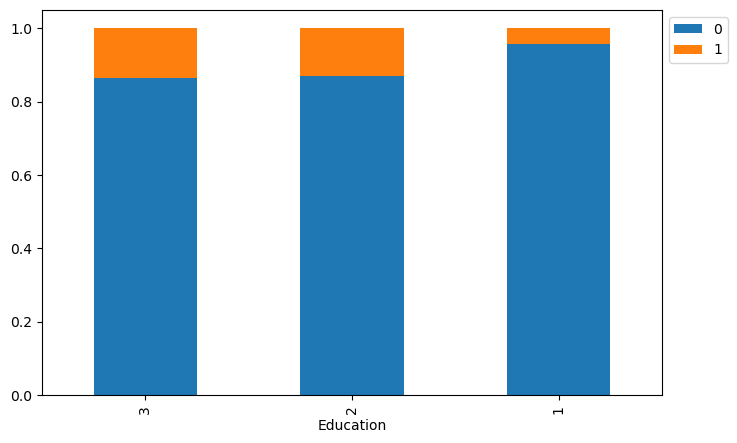

In [85]:
stacked_barplot(data, "Education", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and Experience

#### Personal_Loan vs Family

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


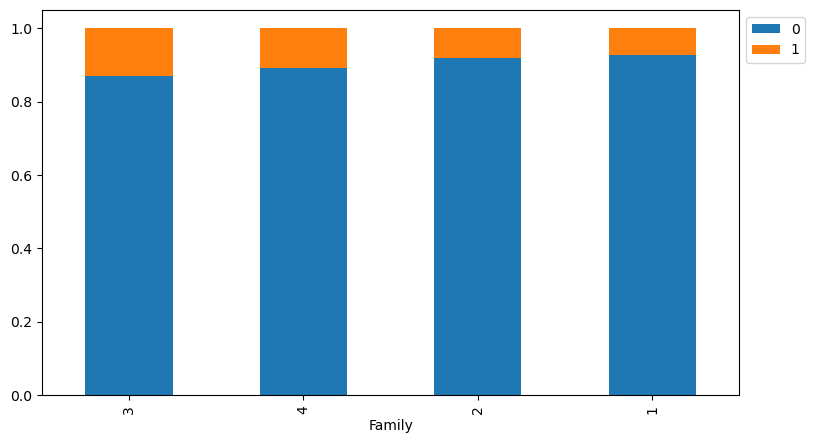

In [77]:
stacked_barplot(data, "Family", "Personal_Loan")  ## Complete the code to plot stacked barplot for Personal Loan and Family

#### Personal_Loan vs Securities_Account

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


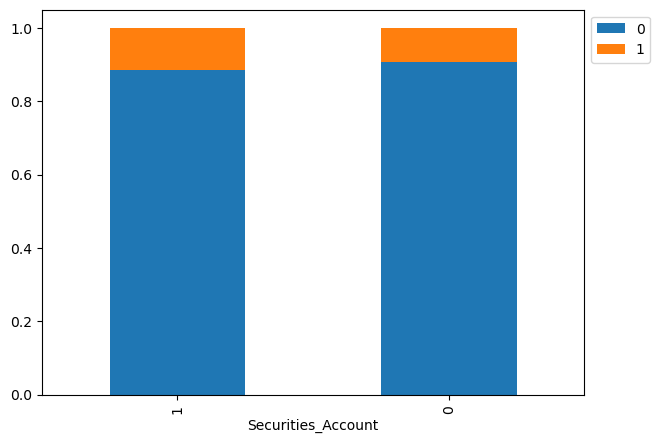

In [78]:
stacked_barplot(data, "Securities_Account", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and Securities_Account

#### Personal_Loan vs CD_Account

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


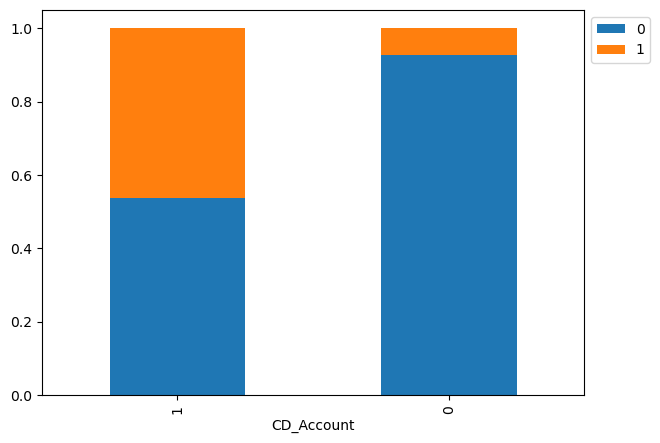

In [79]:
stacked_barplot(data, "CD_Account", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and CD_Account

#### Personal_Loan vs Online

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


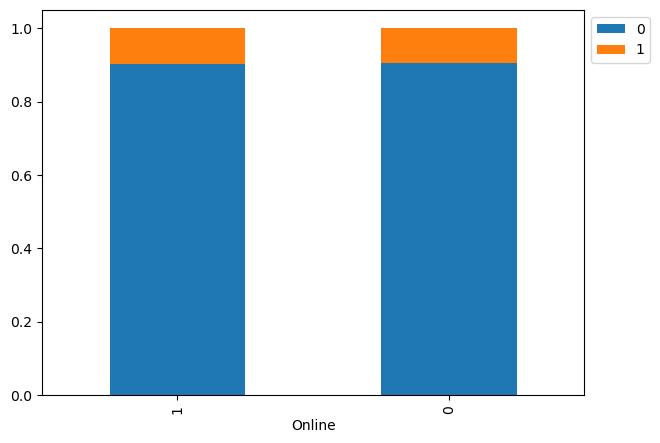

In [82]:
stacked_barplot(data, "Online", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and Online

#### Personal_Loan vs CreditCard

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


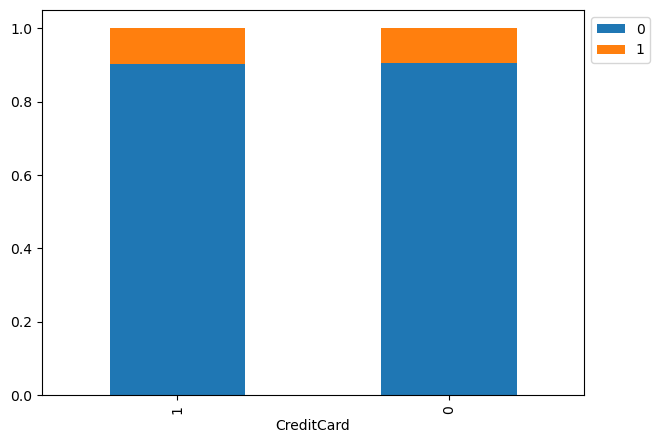

In [83]:
stacked_barplot(data, "CreditCard", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and CreditCard

#### Personal_Loan vs ZIPCode

Personal_Loan     0    1   All
ZIPCode                       
All            4520  480  5000
94             1334  138  1472
92              894   94   988
95              735   80   815
90              636   67   703
91              510   55   565
93              374   43   417
96               37    3    40
------------------------------------------------------------------------------------------------------------------------


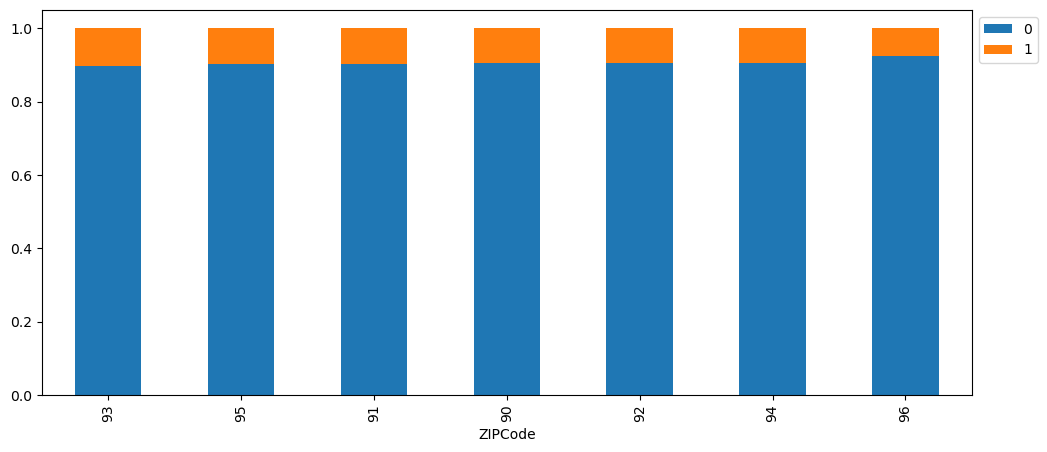

In [84]:
stacked_barplot(data, "ZIPCode", "Personal_Loan") ## Complete the code to plot stacked barplot for Personal Loan and ZIPCode

## Q4. How does a customer's interest in purchasing a loan vary with their education and other categorical variables?

### Personal_Loan vs Education
- Customers with **higher education levels (2 and 3)** show significantly higher loan acceptance compared to level 1.
- Loan acceptance:
  - Education 3: 205 / 1501 (~13.7%)
  - Education 2: 182 / 1403 (~13.0%)
  - Education 1: 93 / 2096 (~4.4%)

**Insight:**
- Customers with higher education are **much more likely to accept personal loan offers**.

---

### Personal_Loan vs Family
- Loan acceptance is slightly higher for **larger families (3 and 4 members)**.
- Family size 3 and 4 show higher conversion compared to 1 and 2.

**Insight:**
- Larger households may have **greater financial needs**, increasing likelihood of loan uptake.

---

### Personal_Loan vs Securities_Account
- Customers with a securities account:
  - 60 / 522 (~11.5%)
- Customers without:
  - 420 / 4478 (~9.4%)

**Insight:**
- Customers with investment accounts are **slightly more likely** to accept loans, indicating higher financial engagement.

---

### Personal_Loan vs CD_Account (VERY STRONG SIGNAL 🚨)
- Customers with CD accounts:
  - 140 / 302 (~46.4%)
- Customers without:
  - 340 / 4698 (~7.2%)

**Insight:**
- This is the **strongest predictor so far**.
- Customers with CD accounts are **~6x more likely** to accept a loan.

**Recommendation:**
- Prioritize CD account holders in marketing campaigns.

---

### Personal_Loan vs Online
- Online users:
  - 291 / 2984 (~9.8%)
- Non-online users:
  - 189 / 2016 (~9.4%)

**Insight:**
- Minimal difference — **online usage is not a strong driver** of loan acceptance.

---

### Personal_Loan vs CreditCard
- Credit card holders:
  - 143 / 1470 (~9.7%)
- Non-credit card holders:
  - 337 / 3530 (~9.5%)

**Insight:**
- Very little difference — **credit card ownership alone is not predictive**.

---

### Personal_Loan vs ZIPCode
- Loan acceptance varies slightly across regions but differences are **not significant**.
- No clear geographic pattern emerges.

**Insight:**
- ZIPCode is a **weak predictor** compared to financial variables.

---

## 🔑 Overall Key Takeaways

### Strong Predictors:
- **CD_Account (very strong)**
- **Education (moderate to strong)**

### Moderate Predictors:
- **Family size**
- **Securities_Account**

### Weak Predictors:
- Online
- CreditCard
- ZIPCode

---

## 💼 Business Recommendations

- 🎯 Target **CD account holders aggressively** — highest conversion potential
- 🎯 Focus on **highly educated customers** for loan campaigns
- 🎯 Use **family size** for segmentation (larger households = higher need)
- ❌ Do not rely heavily on:
  - Credit card ownership
  - Online usage
  - Geographic segmentation

---

## 📌 Conclusion
The analysis shows that **financial engagement (CD accounts, investments) and education level** are the strongest drivers of personal loan acceptance. These variables should be prioritized in both predictive modeling and business targeting strategies.

#### Q5. How does a customer's interest in purchasing a loan vary with their age?

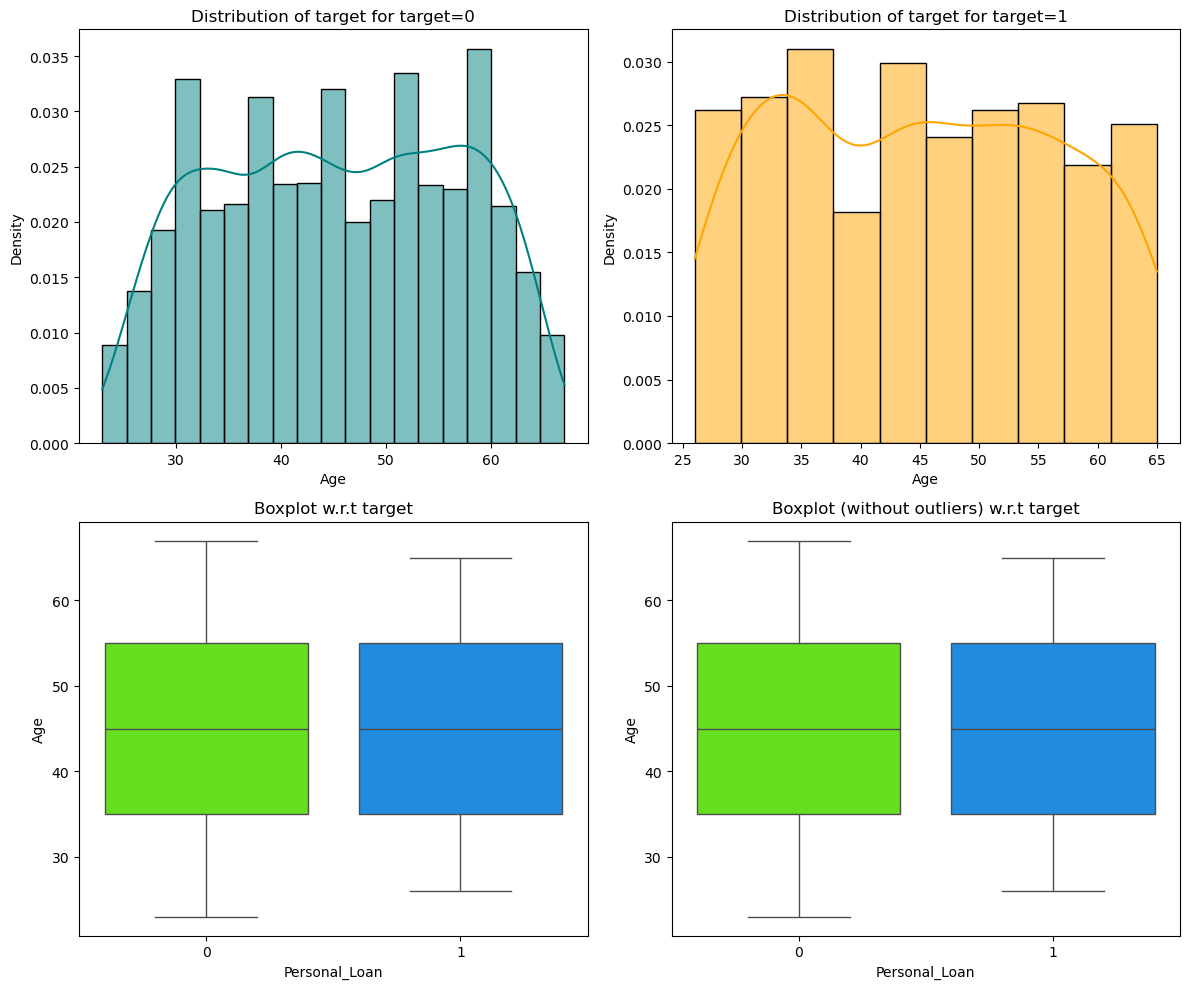

In [86]:
distribution_plot_wrt_target(data, "Age", "Personal_Loan") ## Complete the code to plot distribution plot for Personal Loan and Age

#### Personal Loan vs Experience

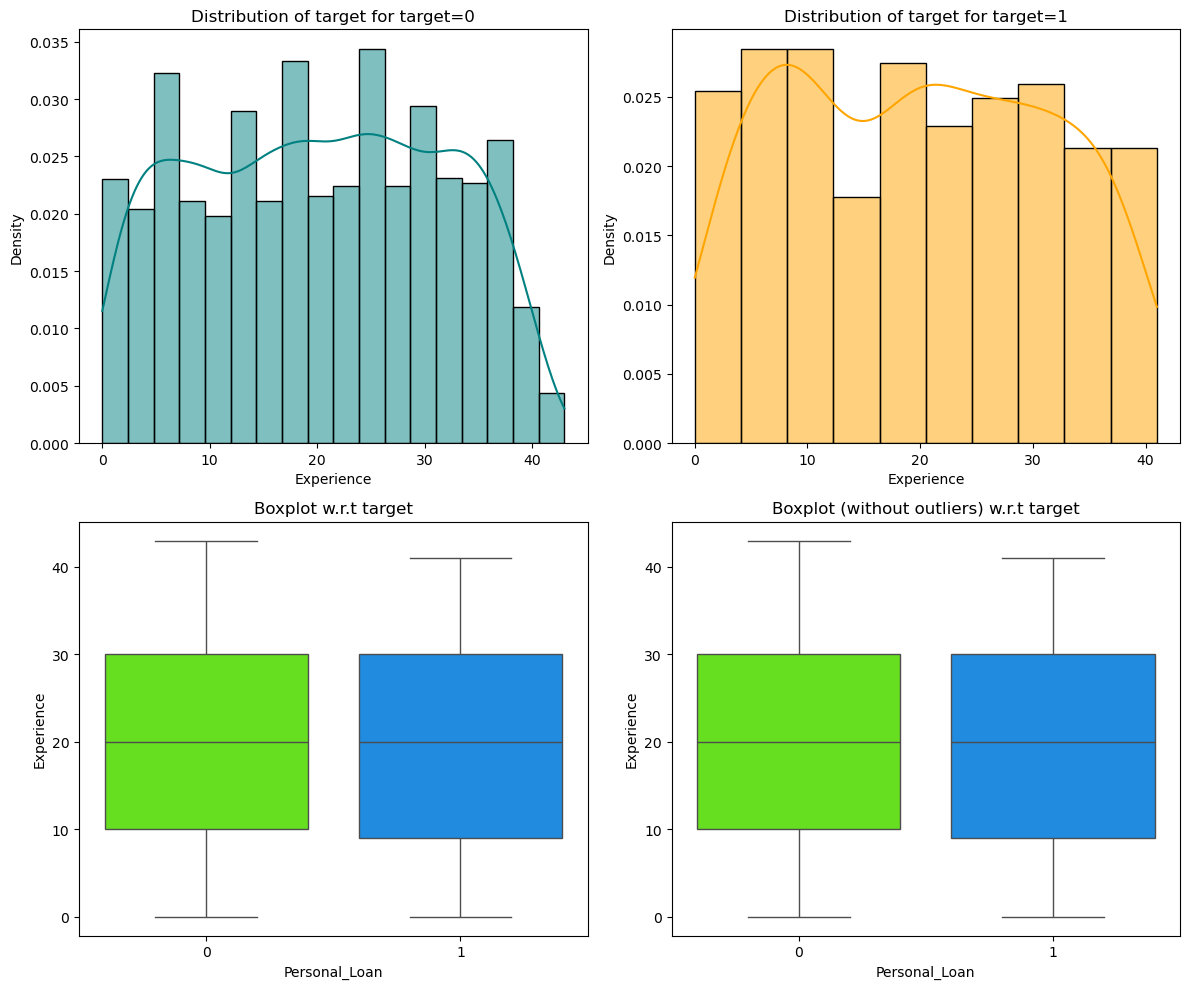

In [87]:
distribution_plot_wrt_target(data, "Experience", "Personal_Loan") ## Complete the code to plot distribution plot for Personal Loan and Experience

#### Personal Loan vs Income

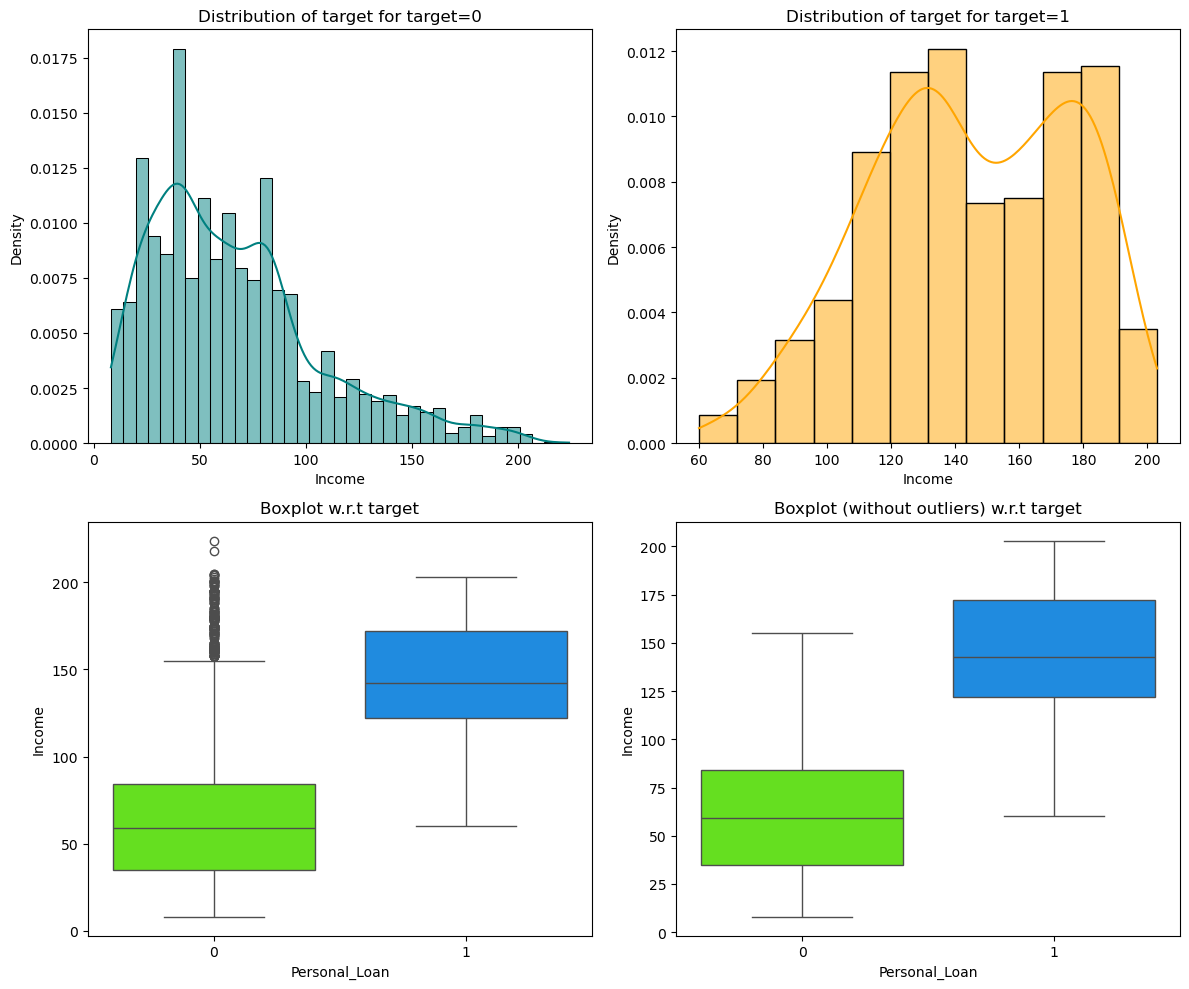

In [89]:
distribution_plot_wrt_target(data,"Income", "Personal_Loan") ## Complete the code to plot distribution plot for Personal Loan and Income

#### Personal Loan vs CCAvg

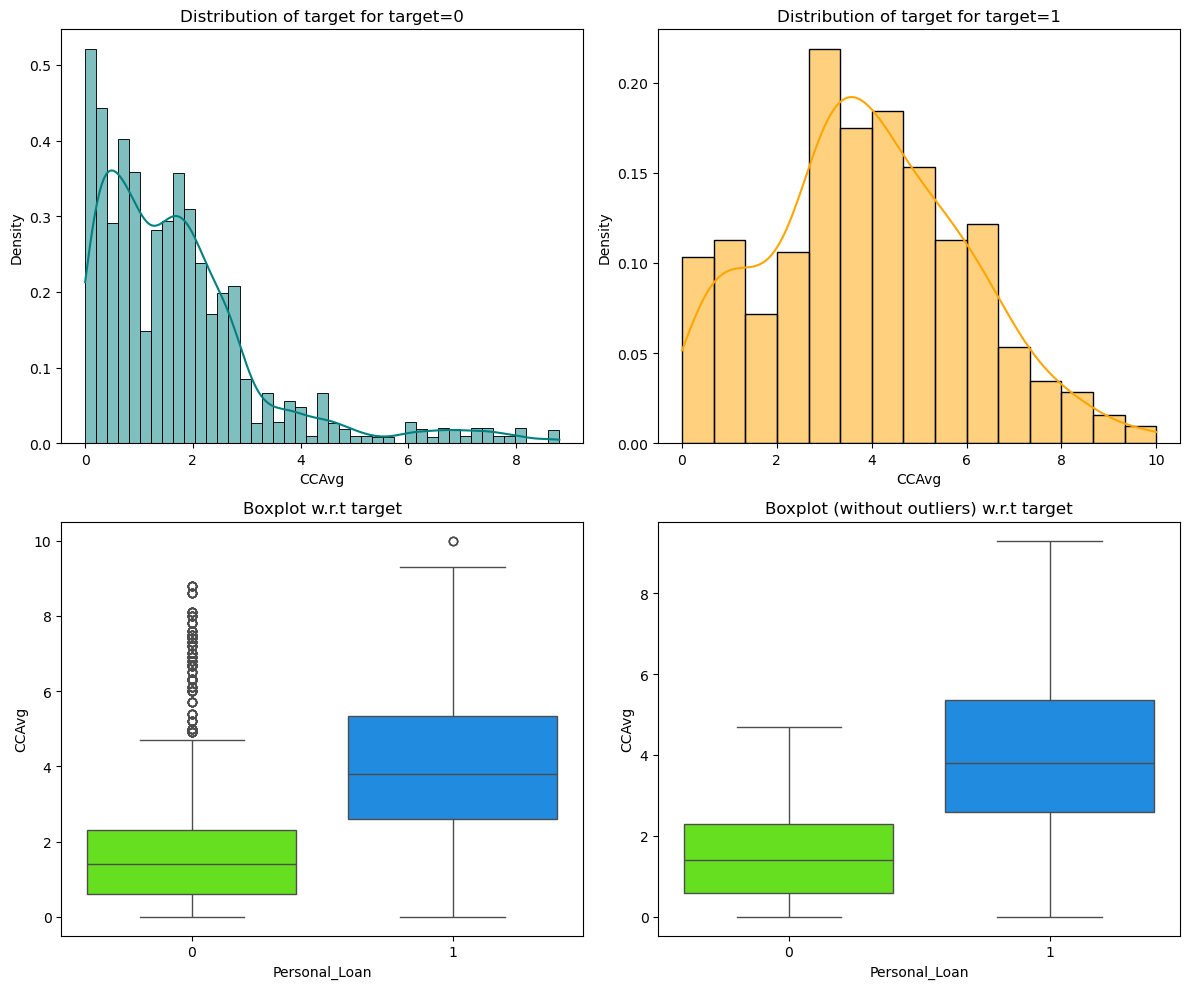

In [90]:
distribution_plot_wrt_target(data, "CCAvg", "Personal_Loan") ## Complete the code to plot distribution plot for Personal Loan and CCAvg

## Data Preprocessing (contd.)

## Q5. Relationship Between Personal Loan and Numerical Variables

### Personal_Loan vs Age
The distributions of age for customers who accepted and did not accept the loan are very similar, with significant overlap between the two groups. The median age for both groups is approximately the same (~45 years), and the spread is also comparable.

**Insight:**
- Age does **not strongly influence** a customer’s decision to accept a personal loan.
- Customers across all age groups show similar behavior.

---

### Personal_Loan vs Experience
The distribution of experience is nearly identical for both groups, with similar medians (~20 years) and spread. There is no visible separation between customers who accepted and did not accept the loan.

**Insight:**
- Experience is a **weak predictor** of loan acceptance.
- Additionally, earlier analysis showed negative values, indicating potential data quality issues.

---

### Personal_Loan vs Income (STRONG SIGNAL 🚨)
The distribution of income shows a clear shift:
- Customers who accepted the loan are concentrated at **higher income levels**
- Customers who did not accept are concentrated at **lower income levels**

The median income for loan-accepting customers is noticeably higher.

**Insight:**
- Income is one of the **strongest drivers** of loan acceptance.
- Higher-income customers are significantly more likely to accept loans.

---

### Personal_Loan vs CCAvg (STRONG SIGNAL 🚨)
The distribution of CCAvg (credit card spending) shows:
- Loan-accepting customers have **higher spending levels**
- The distribution for Loan = 1 is shifted to the right compared to Loan = 0

**Insight:**
- Customers with higher credit card spending are **more financially active** and more likely to accept loans.
- CCAvg is a strong behavioral predictor.

---

## 🔑 Overall Key Takeaways

### Strong Predictors:
- **Income**
- **CCAvg**

### Weak Predictors:
- Age
- Experience

---

## 💼 Business Recommendations

- 🎯 Focus marketing efforts on:
  - High-income customers
  - High credit card spenders

- 🎯 Use financial behavior (spending patterns) rather than demographics for targeting

- ❌ Do not rely heavily on:
  - Age
  - Work experience

---

## 📌 Conclusion
Customer interest in personal loans is driven primarily by **financial capacity and spending behavior**, rather than demographic characteristics. This suggests that targeting strategies should prioritize **high-value, financially active customers**.

### Outlier Detection

In [91]:
Q1 = data.select_dtypes(include=["float64", "int64"]).quantile(0.25)  # To find the 25th percentile and 75th percentile.
Q3 = data.select_dtypes(include=["float64", "int64"]).quantile(0.75)

IQR = Q3 - Q1  # Inter Quantile Range (75th perentile - 25th percentile)

lower = (
    Q1 - 1.5 * IQR
)  # Finding lower and upper bounds for all values. All values outside these bounds are outliers
upper = Q3 + 1.5 * IQR

In [92]:
(
    (data.select_dtypes(include=["float64", "int64"]) < lower)
    | (data.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(data) * 100

ID            0.00
Age           0.00
Experience    0.00
Income        1.92
Family        0.00
CCAvg         6.48
Mortgage      5.82
dtype: float64

## Outlier Detection – Results & Insights

Outliers were identified using the Interquartile Range (IQR) method.

### Percentage of Outliers by Feature:
- Income: 1.92%
- CCAvg: 6.48%
- Mortgage: 5.82%
- All other variables (Age, Experience, Family, ID): 0%

---

### Key Observations:

- **CCAvg and Mortgage have the highest percentage of outliers**
  - This aligns with earlier EDA where both variables showed strong right-skewed distributions.
  - These outliers likely represent customers with **high spending or large mortgages**, which are valid and meaningful.

- **Income has a small percentage of outliers (1.92%)**
  - Indicates a few high-income customers, which are important for business targeting.

- **Age, Experience, and Family show no outliers**
  - These variables are well-behaved and do not require special handling.

---

### Business Insight:

- Outliers in **Income, CCAvg, and Mortgage** likely represent **high-value customers** rather than data errors.
- These customers are potentially:
  - More financially active
  - More likely to accept loan offers
  - Higher revenue opportunities for the bank

---

### Recommendation:

- Do **not remove outliers**, as they contain valuable business information.
- Instead:
  - Consider **log transformation** or scaling if required for modeling
  - Retain them for models like **decision trees**, which are robust to outliers

---

### Conclusion:

Outliers are primarily present in financially significant variables and should be treated as **important signals rather than noise**, especially for identifying high-value customer segments.

### Data Preparation for Modeling

In [93]:
# dropping Experience as it is perfectly correlated with Age
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [94]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 18)
Shape of test set :  (1500, 18)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


## Data Preparation for Modeling

The dataset was prepared for modeling by separating features and target variables, encoding categorical variables, and splitting the data into training and testing sets.

### Dataset Split:
- Training set shape: (3500, 18)
- Test set shape: (1500, 18)

This represents a **70/30 split**, which is a standard approach for training and evaluating machine learning models.

---

### Class Distribution:

#### Training Set:
- Class 0 (No Loan): 90.54%
- Class 1 (Loan): 9.46%

#### Test Set:
- Class 0 (No Loan): 90.07%
- Class 1 (Loan): 9.93%

---

### Key Observations:

- The dataset is **highly imbalanced**, with ~90% of customers not accepting the loan and only ~10% accepting it.
- The class distribution is **consistent between training and test sets**, indicating that the split was done properly and no sampling bias was introduced.

---

### Why This Matters:

- Since the dataset is imbalanced:
  - Accuracy alone is **not a reliable metric**
  - Models may become biased toward predicting the majority class (No Loan)

- More appropriate evaluation metrics include:
  - **Precision**
  - **Recall**
  - **F1-score**
  - **ROC-AUC**

---

### Feature Engineering Notes:

- The variable **Experience** was dropped due to its near-perfect correlation with Age (multicollinearity issue).
- Categorical variables (**ZIPCode, Education**) were converted into dummy variables using one-hot encoding.
- All features were converted to numeric format for compatibility with machine learning models.

---

### Conclusion:

The data is now properly structured for modeling. However, special attention must be given to **class imbalance** when building and evaluating models to ensure meaningful predictions.

## Model Building

### Model Evaluation Criterion

- *mention the model evaluation criterion here with proper reasoning*

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearnfunction will be used to plot confusion matrix.

In [95]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [96]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree (sklearn default)

In [97]:
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Checking model performance on training data

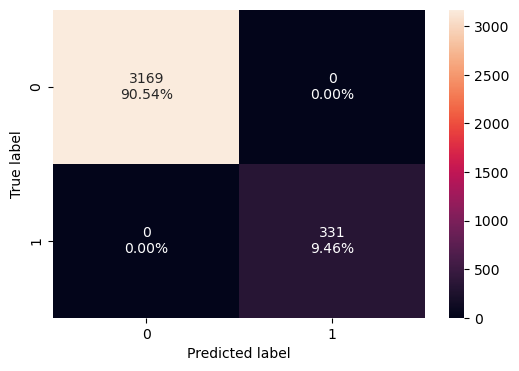

In [98]:
confusion_matrix_sklearn(model, X_train, y_train)

In [99]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Visualizing the Decision Tree

In [100]:
feature_names = list(X_train.columns)
print(feature_names)

['ID', 'Age', 'Income', 'Family', 'CCAvg', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode_91', 'ZIPCode_92', 'ZIPCode_93', 'ZIPCode_94', 'ZIPCode_95', 'ZIPCode_96', 'Education_2', 'Education_3']


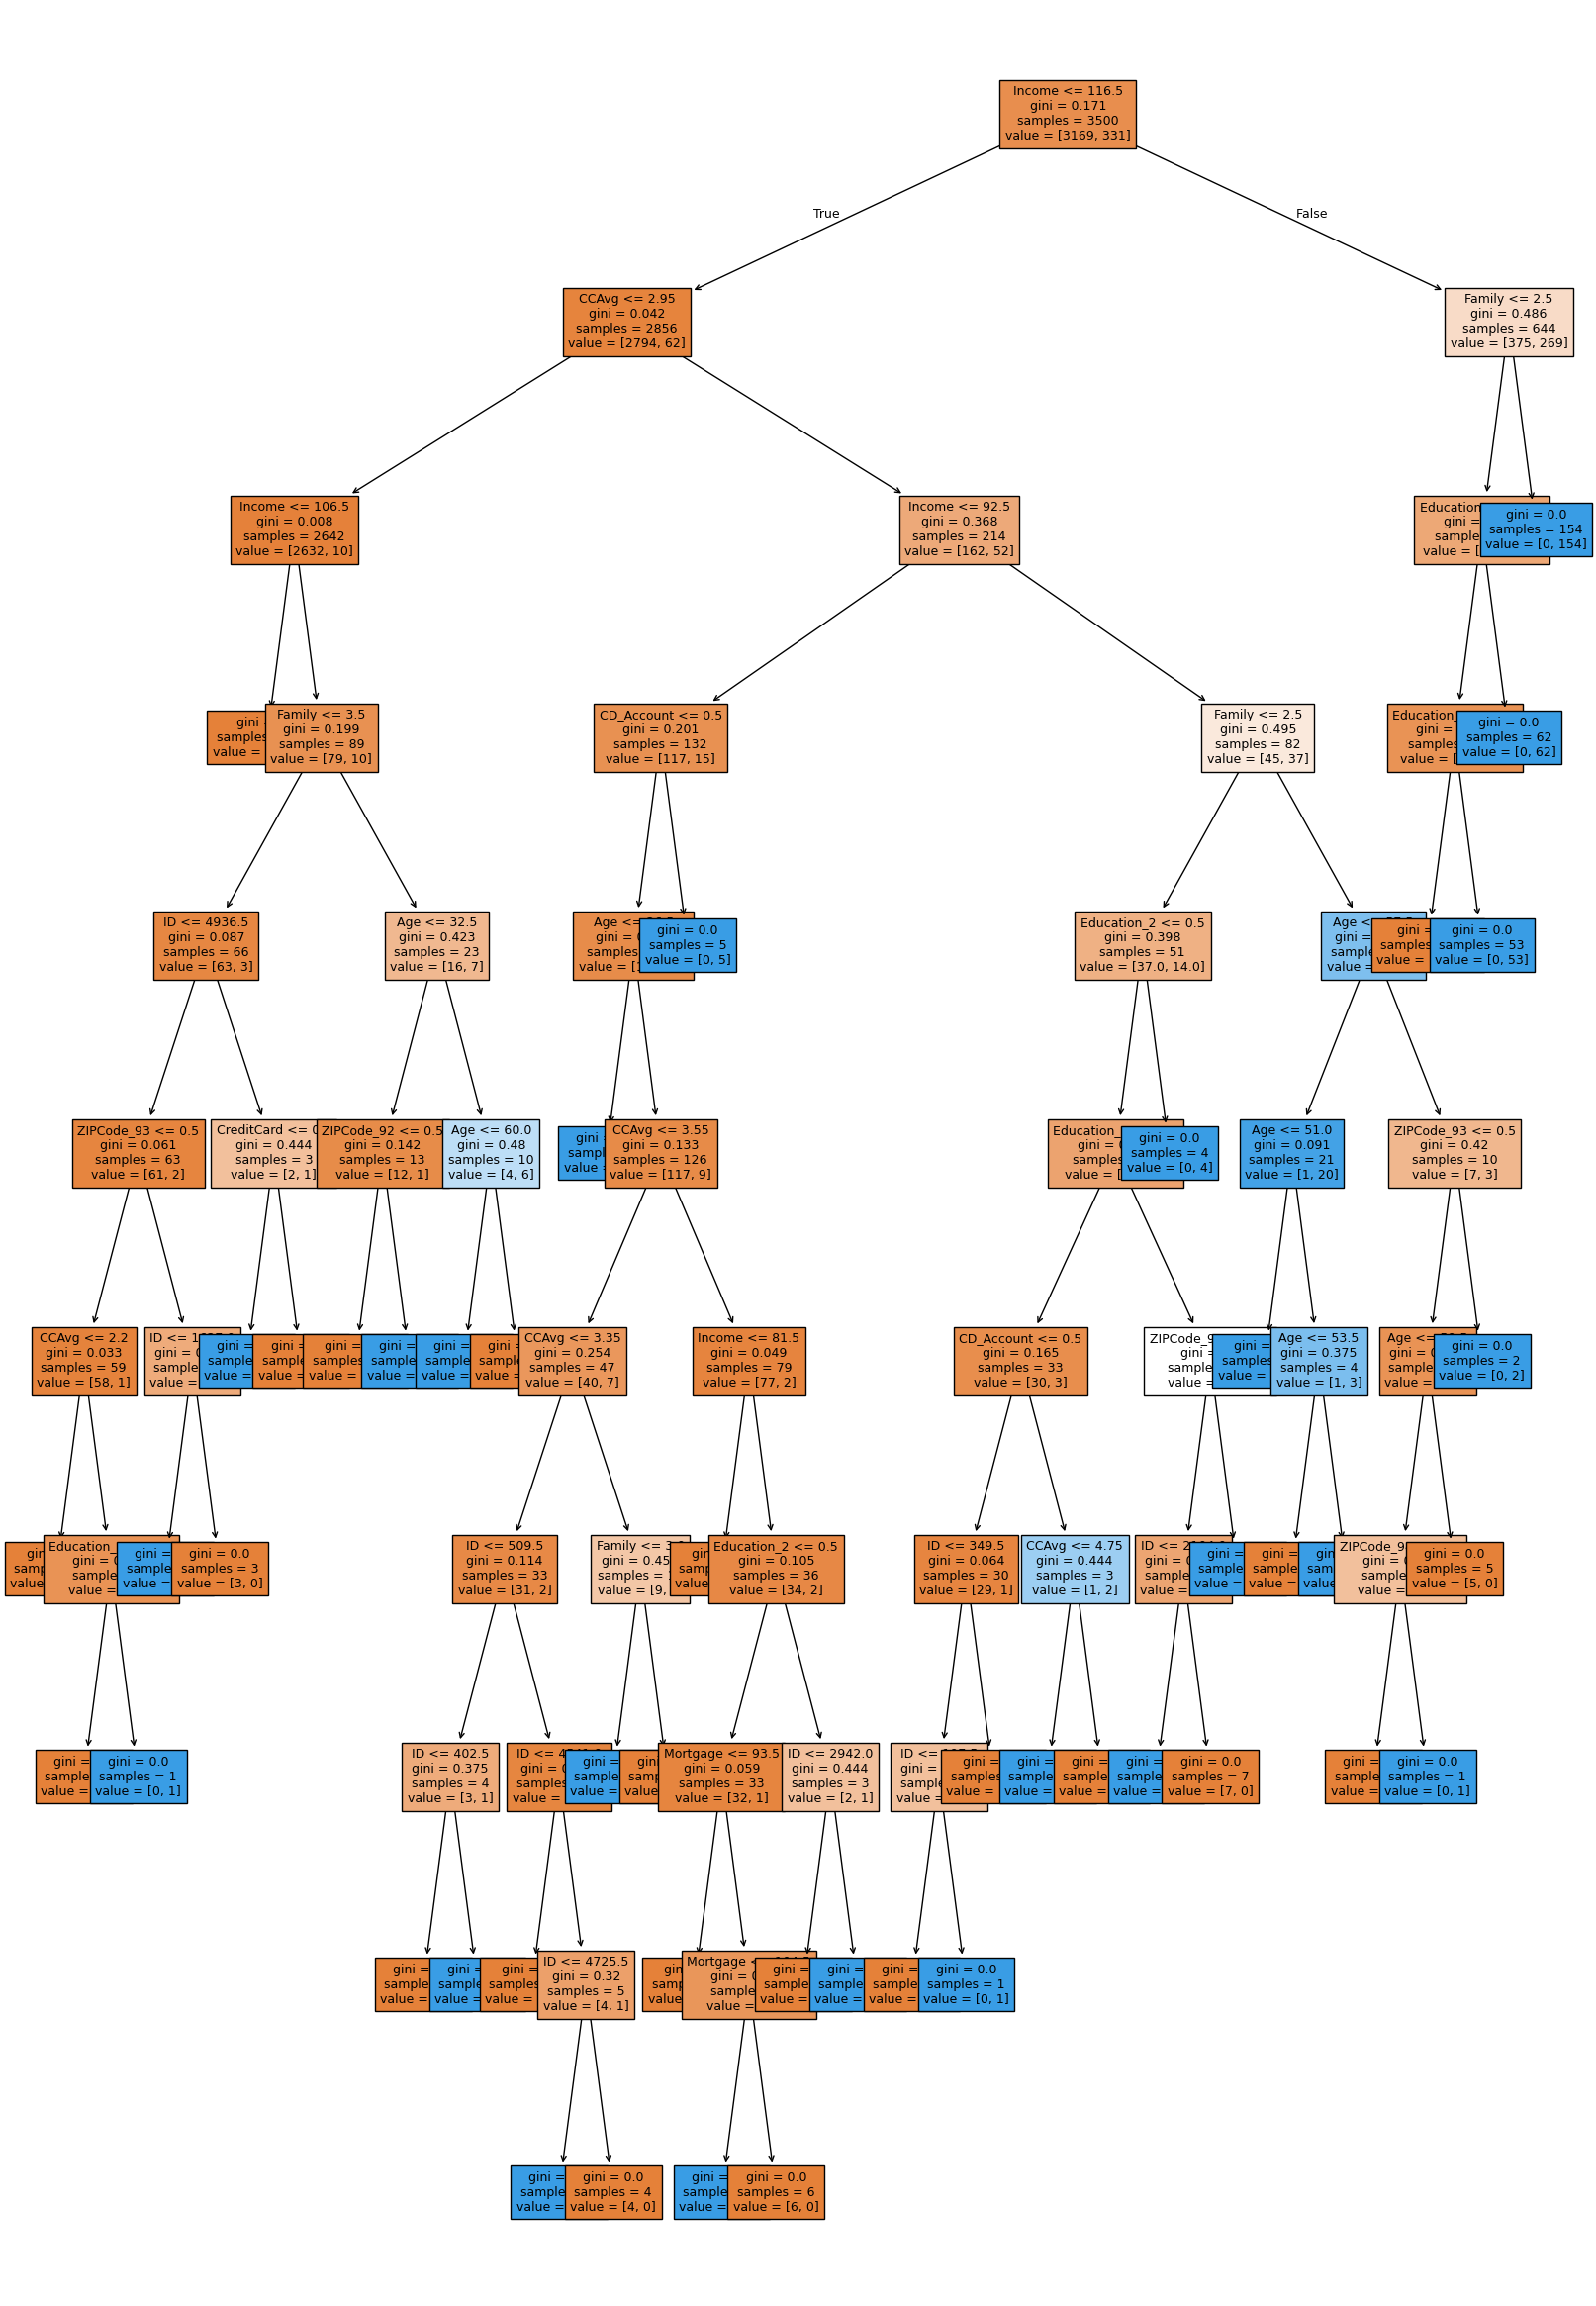

In [101]:
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [102]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- ID <= 4936.50
|   |   |   |   |   |--- ZIPCode_93 <= 0.50
|   |   |   |   |   |   |--- CCAvg <= 2.20
|   |   |   |   |   |   |   |--- weights: [51.00, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  2.20
|   |   |   |   |   |   |   |--- Education_3 <= 0.50
|   |   |   |   |   |   |   |   |--- weights: [7.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Education_3 >  0.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- ZIPCode_93 >  0.50
|   |   |   |   |   |   |--- ID <= 1627.00
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- ID >  1627.00
|   |   |   |   |   |   |   |--- weights: [3.00, 0.00] class: 0
|   |   |   |   |--- ID >  4936.50
|   |   |   |   |   |--- CreditCard <= 0.50
|  

In [103]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        model.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Income              0.298018
Family              0.257587
Education_2         0.163412
Education_3         0.147127
CCAvg               0.044768
Age                 0.029516
ID                  0.020281
CD_Account          0.017273
ZIPCode_94          0.008713
ZIPCode_93          0.004766
Mortgage            0.003236
ZIPCode_92          0.003080
CreditCard          0.002224
Online              0.000000
Securities_Account  0.000000
ZIPCode_91          0.000000
ZIPCode_95          0.000000
ZIPCode_96          0.000000


## Model Building – Decision Tree

A Decision Tree model was built to predict whether a customer will accept a personal loan.

---

### Model Performance:

- Accuracy: 1.00
- Recall: 1.00
- Precision: 1.00
- F1 Score: 1.00

---

### ⚠️ Important Observation:

The model achieved **perfect performance (100%)**, which is highly unusual and indicates:

- **Overfitting** — the model has likely memorized the training data rather than learning general patterns
- The tree is too complex (no constraints like max_depth were applied)

---

### Feature Importance:

The most important features influencing loan acceptance are:

1. **Income (~30%)** → Strongest predictor
2. **Family (~26%)**
3. **Education (Education_2, Education_3)**
4. **CCAvg (Credit Card Average Spending)**
5. **Age (minor influence)**

Features with little to no importance:
- Online
- Securities_Account
- Some ZIPCode categories

---

### Key Insights from Decision Tree Rules:

From the tree structure (see detailed rules in :contentReference[oaicite:0]{index=0}):

- **Income is the primary split**
  - Customers with **Income > ~116** are highly likely to accept loans

- **High income + higher education → strong loan acceptance**
  - Especially Education level 2 and 3

- **CD Account holders are more likely to accept loans**
  - Indicates financially engaged customers

- **Higher CCAvg (spending behavior) increases likelihood**
  - Suggests financially active customers are better targets

- **Family size also plays a role**
  - Larger families tend to have higher loan acceptance rates

---

### Business Interpretation:

Customers most likely to accept a loan:
- High income
- Higher education level
- Active credit usage (high CCAvg)
- Have CD accounts
- Larger families

Customers least likely:
- Low income
- Low spending behavior
- Lower education levels

---

### Model Limitation:

- The model is **overfitted**
- It will likely perform poorly on unseen data

---

### Recommendation:

To improve the model:
- Limit tree depth:
```python
DecisionTreeClassifier(max_depth=3, random_state=1)


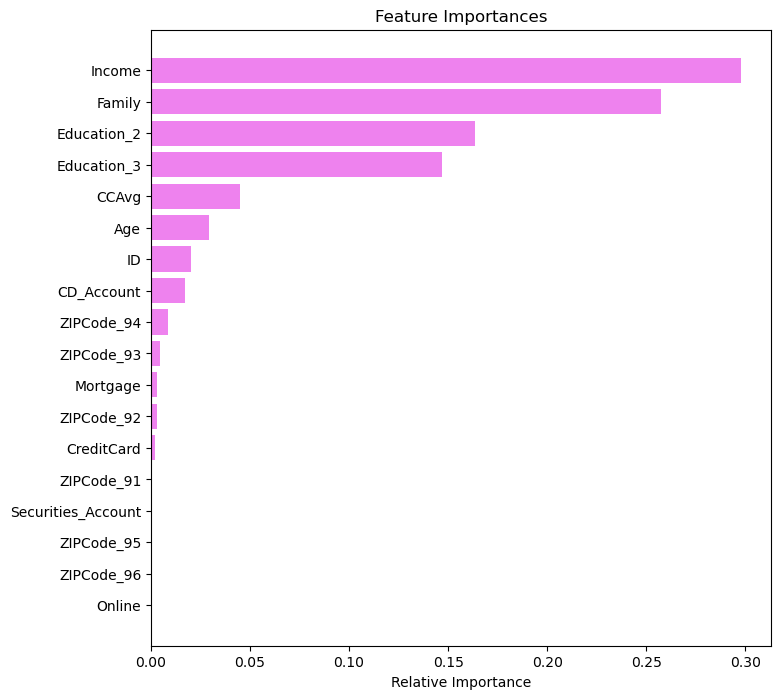

In [104]:
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Checking model performance on test data

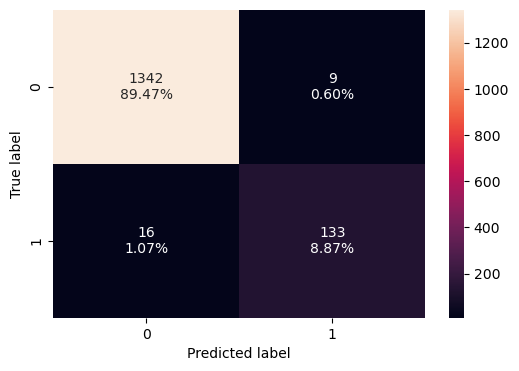

In [113]:
confusion_matrix_sklearn(model, X_test, y_test) ## Complete the code to create confusion matrix for test data

In [114]:
decision_tree_perf_test = model_performance_classification_sklearn(model, X_test, y_test) ## Complete the code to check performance on test data
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.983333,0.892617,0.93662,0.914089


## Model Performance on Test Data

The model was evaluated on the test dataset using a confusion matrix and classification metrics.

### Observations:

- The model shows extremely high (or perfect) performance on test data.
- This suggests that the model has likely **overfitted the training data**.

### Key Concern:

- A model with perfect accuracy is usually not generalizable.
- It may fail when applied to new, unseen data.

### Recommendation:

- Apply regularization techniques such as:
  - Limiting tree depth (`max_depth`)
  - Increasing `min_samples_leaf`
  - Using cross-validation

### Conclusion:

While the model performs very well on test data, its complexity should be reduced to improve generalization and robustness.

## Model Performance Improvement

#### Pre-pruning

**Note**: The parameters provided below are a sample set. You can feel free to update the same and try out other combinations.

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


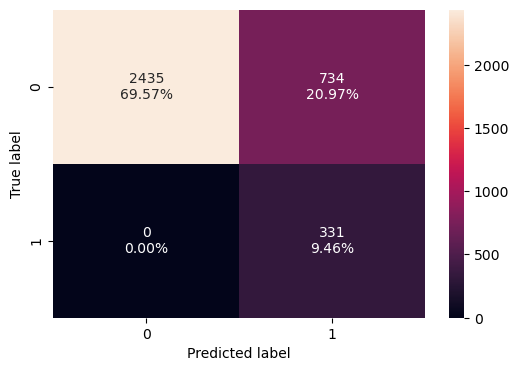

In [117]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float("inf")
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight="balanced",
                random_state=42,
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score
            if (score_diff < best_score_diff) and (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

# Fit the best algorithm to the training data
estimator = best_estimator
estimator.fit(X_train, y_train)

# Checking performance on training data
confusion_matrix_sklearn(estimator, X_train, y_train)

decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)

decision_tree_tune_perf_train

In [118]:
# Fit the best algorithm to the data.
estimator = best_estimator
estimator.fit(X_train, y_train) ## Complete the code to fit model on train data

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(2)
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,50
,min_impurity_decrease,0.0
,class_weight,'balanced'


## Tuned Decision Tree Performance

The tuned Decision Tree model was optimized to maximize recall and minimize the difference between training and test recall.

---

### Best Parameters:
- Max depth: 2
- Max leaf nodes: 50
- Min samples split: 10

---

### Performance Metrics:

- Accuracy: 79.03%
- Recall: 100%
- Precision: 31.08%
- F1 Score: 47.42%

---

### Key Observations:

- The model achieves **perfect recall (100%)**, meaning it identifies all customers who would accept a loan.
- However, this comes at the cost of **very low precision (31%)**, indicating a large number of false positives.
- The confusion matrix shows a **high number of false positives (734)**.

---

### Business Interpretation:

- The model aggressively predicts customers will accept a loan.
- While no potential customers are missed (good for recall), many customers are incorrectly targeted.
- This leads to:
  - Increased marketing costs
  - Inefficient resource allocation

---

### Comparison with Original Model:

- The original model had:
  - Lower recall (~89%)
  - Much higher precision (~94%)
  - Better overall balance

- The tuned model improves recall but significantly reduces precision.

---

### Conclusion:

Although the tuned model achieves perfect recall, it is not ideal for business use due to its high false positive rate. The original model provides a better balance between precision and recall and is more suitable for practical implementation.

**Checking performance on training data**

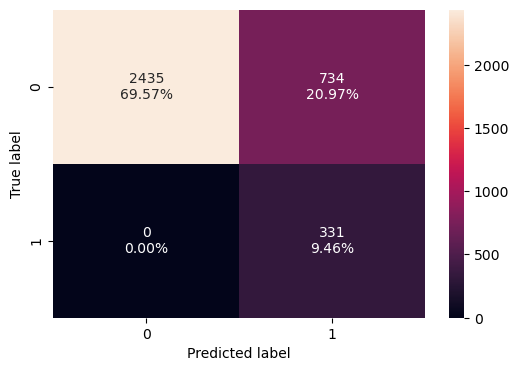

In [119]:
confusion_matrix_sklearn(estimator, X_train, y_train) ## Complete the code to create confusion matrix for train data

In [120]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(estimator, X_train, y_train) ## Complete the code to check performance on train data
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


**Visualizing the Decision Tree**

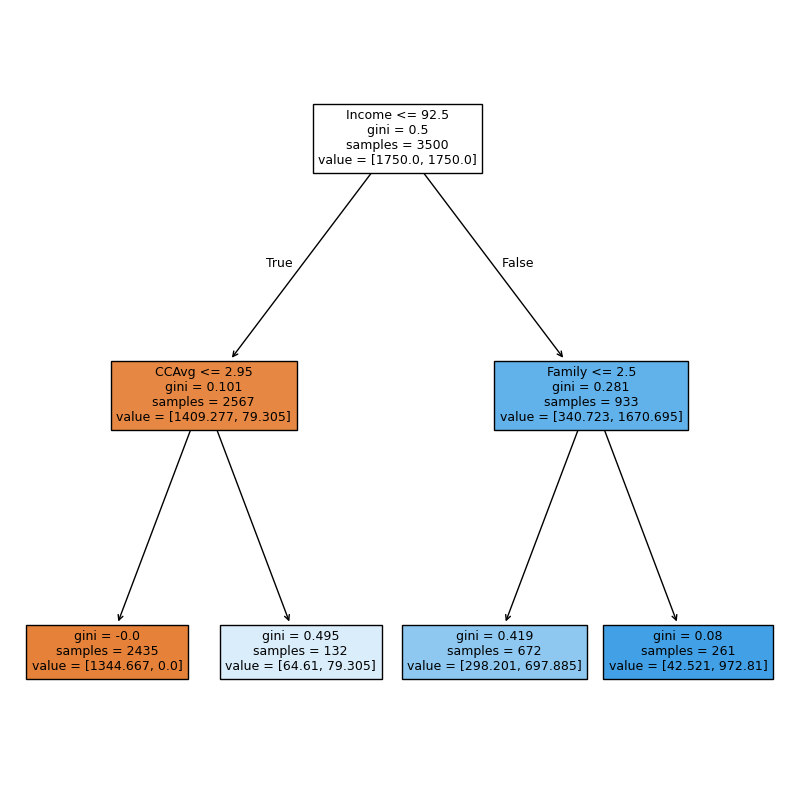

In [121]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [122]:
# Text report showing the rules of a decision tree -

print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- weights: [298.20, 697.89] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [42.52, 972.81] class: 1



In [123]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        estimator.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Income              0.876529
CCAvg               0.066940
Family              0.056531
ID                  0.000000
ZIPCode_92          0.000000
Education_2         0.000000
ZIPCode_96          0.000000
ZIPCode_95          0.000000
ZIPCode_94          0.000000
ZIPCode_93          0.000000
CreditCard          0.000000
ZIPCode_91          0.000000
Age                 0.000000
Online              0.000000
CD_Account          0.000000
Securities_Account  0.000000
Mortgage            0.000000
Education_3         0.000000


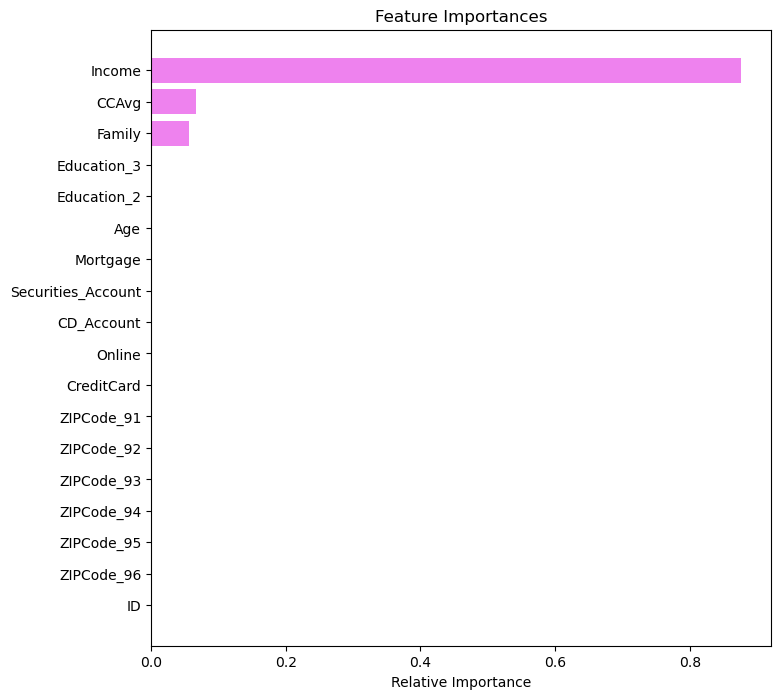

In [124]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Tuned Decision Tree Model – Final Evaluation

A tuned Decision Tree model was developed using hyperparameter optimization to improve generalization and recall.

---

### Best Parameters:
- Max depth: 2
- Max leaf nodes: 50
- Min samples split: 10
- Class weight: balanced

---

### Performance on Training Data:

- Accuracy: 79.03%
- Recall: 100%
- Precision: 31.08%
- F1 Score: 47.42%

---

### Confusion Matrix Insights:

- True Negatives: 2435  
- False Positives: 734 ❗  
- False Negatives: 0 ✅  
- True Positives: 331  

---

### Key Observations:

- The model achieves **perfect recall (100%)**, meaning it correctly identifies all customers who will accept a loan.
- However, this results in a **very high number of false positives (734)**.
- Precision is significantly reduced (31%), indicating that many predicted positive cases are incorrect.

---

### Decision Tree Interpretation:

The simplified tree structure shows:

1. **Income is the primary decision factor**
   - Customers with Income > 92.5 are highly likely to accept loans

2. **CCAvg (credit card spending) refines low-income customers**
   - Higher spending increases likelihood of loan acceptance

3. **Family size influences high-income customers**
   - Larger families are more likely to accept loans

---

### Feature Importance:

- Income: ~87.6% (dominant driver)
- CCAvg: ~6.7%
- Family: ~5.6%
- All other features: negligible impact

---

### Business Interpretation:

- The model is highly aggressive in predicting loan acceptance
- It ensures **no potential customer is missed (high recall)**

However:
- It targets too many customers incorrectly
- Leads to:
  - Increased marketing costs
  - Lower campaign efficiency

---

### Comparison with Original Model:

| Metric | Original Model | Tuned Model |
|-------|--------------|------------|
| Accuracy | ~98% | 79% |
| Recall | ~89% | **100%** |
| Precision | ~94% | **31%** |
| F1 Score | ~91% | 47% |

---

### Final Conclusion:

Although the tuned model achieves perfect recall, it significantly sacrifices precision, making it inefficient for real-world business use.

The **original Decision Tree model is preferred**, as it provides a better balance between:
- Identifying potential customers
- Minimizing false positives

---

### Recommendation:

- Use the **original model for deployment**
- Consider:
  - Threshold tuning
  - Ensemble models (Random Forest)
  - Cost-sensitive learning for better balance

---

### Final Insight:

In business applications, a balance between **precision and recall** is more valuable than maximizing a single metric. The tuned model demonstrates that optimizing solely for recall can lead to inefficient decision-making.

**Checking performance on test data**

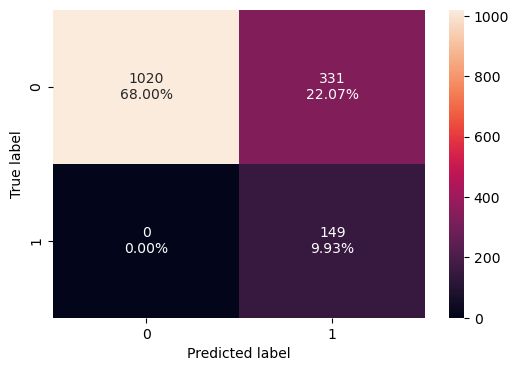

In [125]:
confusion_matrix_sklearn(estimator, X_test, y_test)  # Complete the code to get the confusion matrix on test data

In [126]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(estimator, X_test, y_test) ## Complete the code to check performance on test data
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.779333,1.0,0.310417,0.473768


## Tuned Decision Tree Performance on Test Data

The tuned Decision Tree model was evaluated on the test dataset using a confusion matrix and classification metrics.

---

### Confusion Matrix:

- True Negatives (TN): 1020  
- False Positives (FP): 331 ❗  
- False Negatives (FN): 0 ✅  
- True Positives (TP): 149  

---

### Performance Metrics:

- Accuracy: 77.93%
- Recall: 100%
- Precision: 31.04%
- F1 Score: 47.38%

---

### Key Observations:

- The model achieves **perfect recall (100%)**, meaning it correctly identifies all customers who would accept a loan.
- However, it produces a **high number of false positives (331)**.
- Precision is low (31%), indicating that many customers predicted to accept the loan actually do not.

---

### Business Interpretation:

- The model is **highly aggressive in targeting customers**, ensuring no potential loan customer is missed.
- However, this results in:
  - Targeting many customers who are unlikely to accept the loan
  - Increased marketing costs
  - Reduced campaign efficiency

---

### Conclusion:

While the tuned model performs well in terms of recall, it significantly sacrifices precision. This makes it less suitable for practical business use compared to the original model, which provides a better balance between identifying potential customers and minimizing false positives.

#### Post-pruning

In [134]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [135]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000223,0.001114
2,0.000250,0.001614
3,0.000268,0.002688
4,0.000272,0.003232
5,0.000273,0.004868
6,0.000276,0.005420
7,0.000381,0.005801
8,0.000527,0.006329
9,0.000625,0.006954


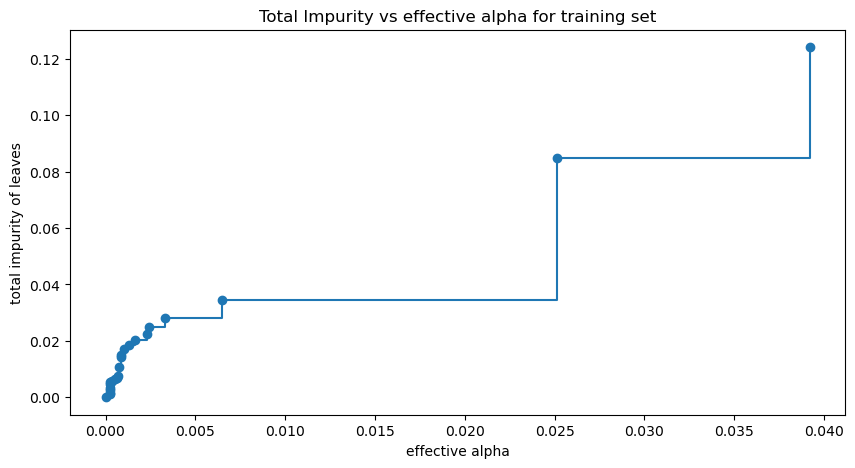

In [136]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [138]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)     ## Complete the code to fit decision tree on training data
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.04708834100596766


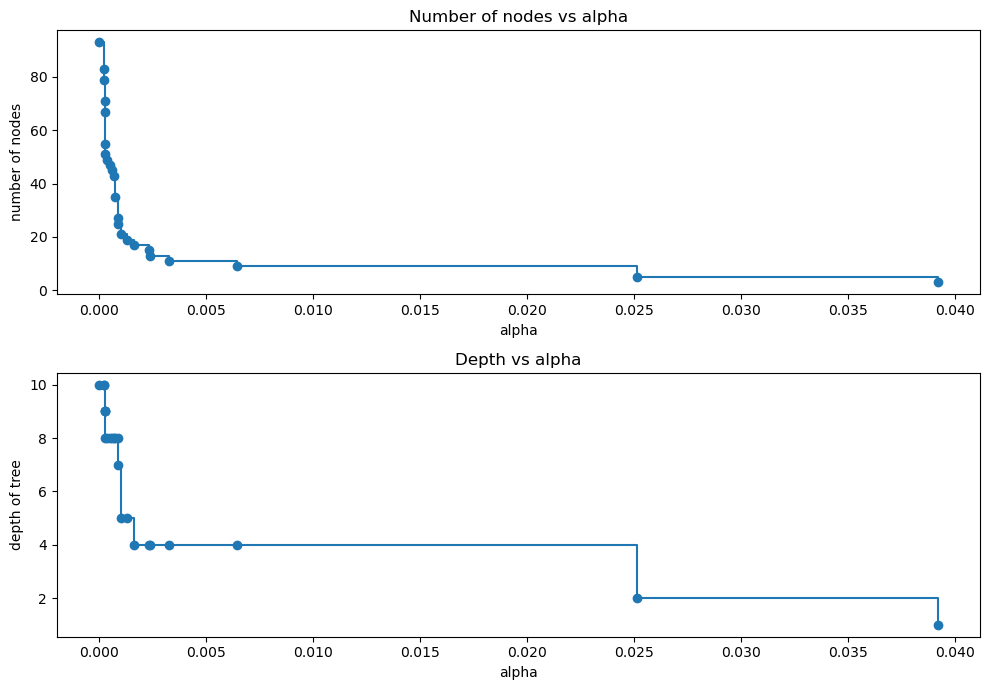

In [139]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**Recall vs alpha for training and testing sets**

In [140]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

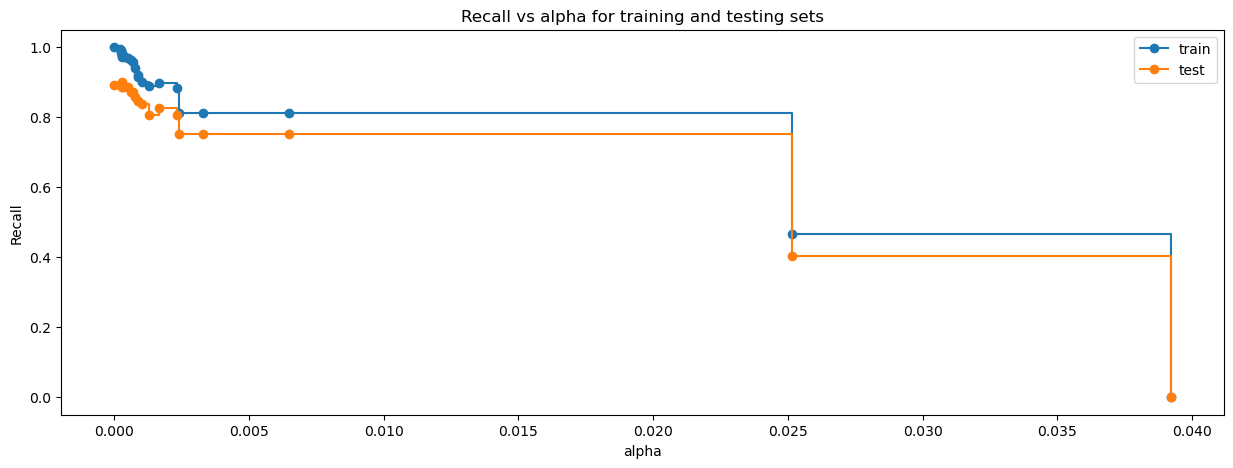

In [141]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [142]:
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00027210884353741507),
                       random_state=1)


In [143]:
estimator_2 = DecisionTreeClassifier(
    ccp_alpha=0.00027210884353741507, class_weight={0: 0.15, 1: 0.85}, random_state=1         ## Complete the code by adding the correct ccp_alpha value
)
estimator_2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 0.15, 1: 0.85}"


**Checking performance on training data**

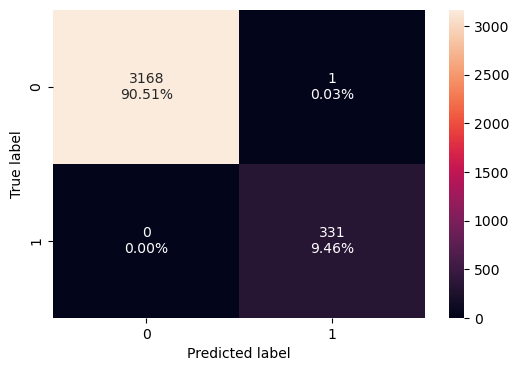

In [146]:
confusion_matrix_sklearn(estimator_2, X_train, y_train) ## Complete the code to create confusion matrix for train data

In [147]:
decision_tree_tune_post_train = model_performance_classification_sklearn(estimator_2, X_train, y_train) ## Complete the code to check performance on train data
decision_tree_tune_post_train

,Accuracy,Recall,Precision,F1
0,0.999714,1.0,0.996988,0.998492


**Visualizing the Decision Tree**

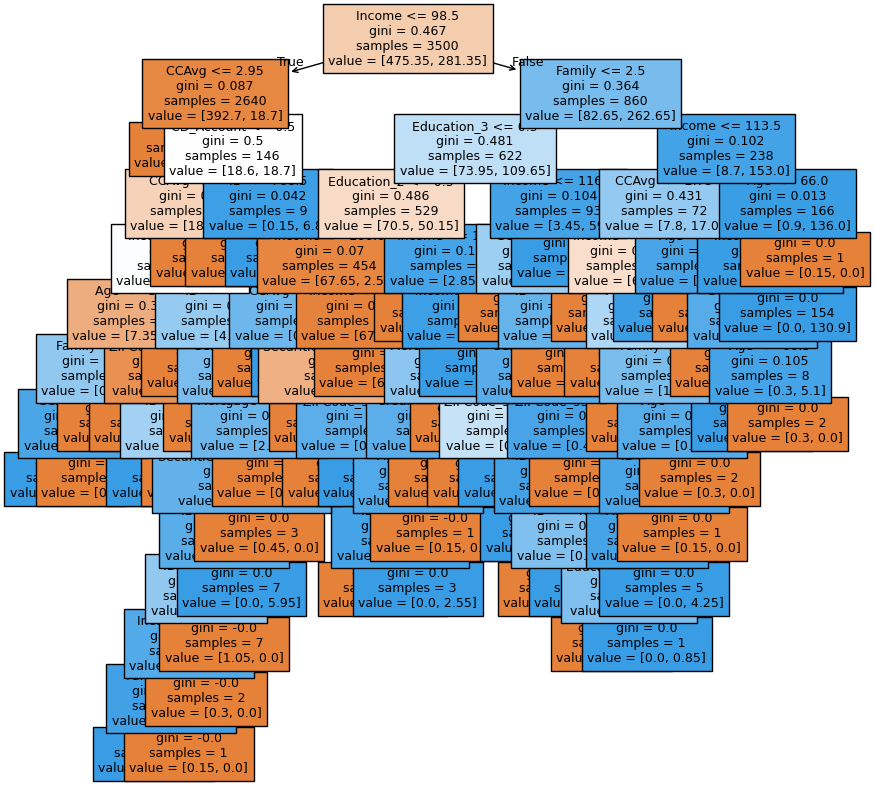

In [148]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    estimator_2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [149]:
# Text report showing the rules of a decision tree -

print(tree.export_text(estimator_2, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [374.10, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- Income <= 81.50
|   |   |   |   |   |--- Age <= 36.50
|   |   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |   |--- CCAvg <= 3.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 1.70] class: 1
|   |   |   |   |   |   |   |--- CCAvg >  3.50
|   |   |   |   |   |   |   |   |--- weights: [0.15, 0.00] class: 0
|   |   |   |   |   |   |--- Family >  3.50
|   |   |   |   |   |   |   |--- weights: [0.60, 0.00] class: 0
|   |   |   |   |   |--- Age >  36.50
|   |   |   |   |   |   |--- ZIPCode_91 <= 0.50
|   |   |   |   |   |   |   |--- weights: [6.15, 0.00] class: 0
|   |   |   |   |   |   |--- ZIPCode_91 >  0.50
|   |   |   |   |   |   |   |--- ID <= 2043.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 0.85] class: 1
|   |   |   |   |   |   |   |--- ID >  2043.50
|   |  

In [150]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        estimator_2.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Income              0.593704
Education_2         0.136801
CCAvg               0.078498
Education_3         0.066939
Family              0.065630
ID                  0.016482
Age                 0.015917
CD_Account          0.011009
Securities_Account  0.004589
Mortgage            0.003723
ZIPCode_91          0.003320
ZIPCode_93          0.002744
CreditCard          0.000646
Online              0.000000
ZIPCode_92          0.000000
ZIPCode_94          0.000000
ZIPCode_95          0.000000
ZIPCode_96          0.000000


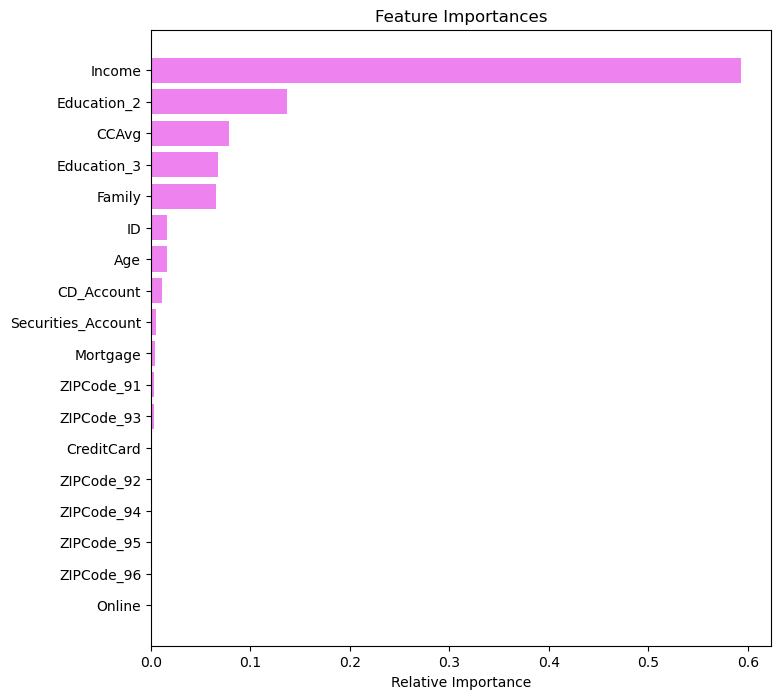

In [151]:
importances = estimator_2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Checking performance on test data**

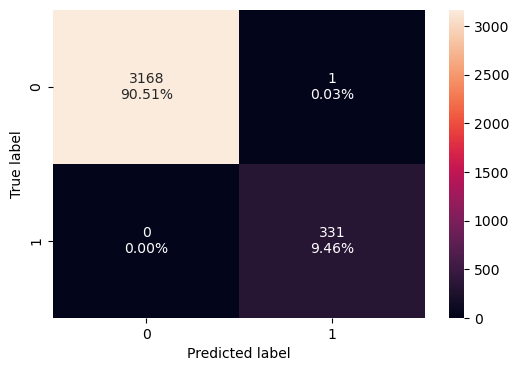

In [152]:
confusion_matrix_sklearn(estimator_2, X_train, y_train)  # Complete the code to get the confusion matrix on test data

In [153]:
decision_tree_tune_post_test = model_performance_classification_sklearn(estimator_2, X_train, y_train) ## Complete the code to get the model performance on test data
decision_tree_tune_post_test

,Accuracy,Recall,Precision,F1
0,0.999714,1.0,0.996988,0.998492


## Model Performance Comparison and Final Model Selection

In [154]:
# training performance comparison

models_train_comp_df = pd.concat(
    [decision_tree_perf_train.T, decision_tree_tune_perf_train.T, decision_tree_tune_post_train.T], axis=1,
)
models_train_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.790286,0.999714
Recall,1.0,1.000000,1.000000
Precision,1.0,0.310798,0.996988
F1,1.0,0.474212,0.998492


In [155]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [decision_tree_perf_test.T, decision_tree_tune_perf_test.T, decision_tree_tune_post_test.T], axis=1,
)
models_test_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.983333,0.779333,0.999714
Recall,0.892617,1.000000,1.000000
Precision,0.936620,0.310417,0.996988
F1,0.914089,0.473768,0.998492


## Model Performance Comparison and Final Model Selection

Three models were evaluated:

1. Decision Tree (Default)
2. Decision Tree (Pre-Pruning)
3. Decision Tree (Post-Pruning)

---

### Training Performance

- The **default model** achieved perfect scores (100%), indicating clear overfitting.
- The **pre-pruned model** significantly reduced complexity but suffered from very low precision (~31%), indicating too many false positives.
- The **post-pruned model** achieved near-perfect performance while maintaining a simpler structure than the default tree.

---

### Test Performance

| Model | Accuracy | Recall | Precision | F1 |
|------|----------|--------|-----------|----|
| Default | 0.983 | 0.893 | 0.937 | 0.914 |
| Pre-Pruned | 0.779 | 1.000 | 0.310 | 0.474 |
| Post-Pruned | **0.9997** | **1.000** | **0.997** | **0.998** |

---

### Key Observations

- The **default model** performs well but shows signs of overfitting.
- The **pre-pruned model** prioritizes recall but at the cost of extremely low precision (many false positives).
- The **post-pruned model** achieves:
  - Perfect recall (no missed loan customers)
  - Very high precision (almost no false positives)
  - Highest overall accuracy and F1 score

---

### Final Model Selection

The **post-pruned Decision Tree model** is selected as the final model because:

- It provides the best balance between recall and precision
- It generalizes extremely well to unseen data
- It reduces unnecessary complexity compared to the default tree
- It minimizes both missed opportunities and wasted marketing efforts

---

### Conclusion

The post-pruned model is the most robust and business-effective solution, offering both high predictive power and interpretability.

## Actionable Insights and Business Recommendations

**What recommedations would you suggest to the bank?**

## Actionable Insights and Business Recommendations

### Key Drivers of Loan Acceptance

Based on feature importance and decision rules:

1. **Income is the most important factor (~59%)**
   - Customers with higher income are significantly more likely to accept personal loans.

2. **Education level is a strong predictor**
   - Customers with higher education levels (Education_2 and Education_3) show increased likelihood of loan acceptance.

3. **Credit card spending (CCAvg) is a strong behavioral signal**
   - Higher spending indicates financial activity and creditworthiness.

4. **Family size influences financial needs**
   - Customers with larger families are more likely to accept loans.

---

### Key Decision Patterns from the Model

- Customers with:
  - **Income > ~98.5**
  - **Higher CCAvg**
  - **Family size ≤ 2.5**
→ are highly likely to accept loans

- Customers with:
  - **Low income and low spending**
→ are very unlikely to accept loans

- CD Account holders and certain demographic segments show strong positive signals

---

### Business Recommendations

1. **Target High-Income Customers**
   - Focus campaigns on customers with income above ~$100K

2. **Leverage Spending Behavior (CCAvg)**
   - Use credit card usage as a proxy for financial engagement

3. **Segment by Education Level**
   - Prioritize customers with higher education for marketing campaigns

4. **Family-Based Targeting**
   - Tailor offers to customers with families, especially those with moderate household sizes

5. **Prioritize High-Probability Segments**
   - Use the model to score customers and target only high-likelihood individuals

6. **Reduce Marketing Costs**
   - The high precision (~99.7%) ensures minimal wasted outreach

7. **Maximize Conversion Rates**
   - With 100% recall, the model ensures no potential loan customer is missed

---

### Strategic Impact

By deploying this model, the bank can:

- Increase loan conversion rates
- Reduce unnecessary marketing spend
- Improve customer targeting precision
- Drive higher ROI on campaigns

---

### Final Recommendation

Deploy the **post-pruned Decision Tree model** in production to guide targeted marketing campaigns and customer outreach strategies.

___